In [67]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from IPython.display import display

In [68]:
def calculate_lead_score(data, gates, modifiers, weights):
    
    b  = data[0]["b"]
    d  = data[0]["d"]
    br = min(b / d, 1)
    c  = data[0]["c"]
    t  = data[0]["t"]
    f1 = 1 - (t / 12)
    f2 = data[0]["f2"]
    m  = data[0]["m"]
    p  = data[0]["p"]
    x1 = 0.45*br + 0.17*c + 0.12*f1 + 0.12*f2 + 0.08*m + 0.06*p

    r  = data[1]["r"]
    s  = data[1]["s"]
    p2 = data[1]["p"]
    cs = data[1]["cs"]
    d2 = data[1]["d"]
    t2 = data[1]["t"]
    c2 = data[1]["c"]
    c3 = data[1]["c2"]
    u  = data[1]["u"]
    fp = 0.25*r + 0.3*s + 0.2*p2 + 0.25*t2
    fn = 1 - 0.4*d2*cs - 0.25*c2 - 0.35*(1 - c3)
    x2 = 0.45*fp + 0.40*fn + 0.15*min(u / 6, 1)

    r3 = data[2]["r"]
    d3 = data[2]["d"]
    n3 = data[2]["n"]
    o3 = data[2]["o"]
    p3 = data[2]["p"]
    ac = r3 * d3
    n3_norm = min(n3 / 5, 1)
    x3 = 0.3*ac + 0.3*n3_norm + 0.25*o3 + 0.15*p3

    t4  = data[3]["t"]
    t1  = data[3]["t1"]
    t2b = data[3]["t2"]
    ep  = data[3]["ep"]
    ns  = data[3]["ns"]
    cp  = data[3]["cp"]

    if t4 <= 30:
        t_prime = 1.0
    elif t4 <= 180:
        t_prime = 1 - (t4 - 30) / 150
    else:
        t_prime = max(0, 0.1 - (t4 - 180) / 1800)

    u_trig = t1 * max(0, 1 - t2b / 180)
    p_prime = 0.5*ep + 0.5*ns
    cp_prime = 1 - 0.3*cp
    x4 = cp_prime * (0.5*t_prime + 0.2*u_trig + 0.3*p_prime)

    n1 = data[4]["n1"];  n2 = data[4]["n2"];  n3e = data[4]["n3"]
    n4 = data[4]["n4"];  n5 = data[4]["n5"];  n6  = data[4]["n6"]
    n7 = data[4]["n7"];  n8 = data[4]["n8"];  n9  = data[4]["n9"]
    t5 = data[4]["t"];   v5 = data[4]["v"];   c5  = data[4]["c"]
    m5 = data[4]["m"]

    er = n1 + 3*n2 + 8*n3e + 5*n4 + 2*n5 + 4*n6 + 6*n7 + 10*n8 + 2*n9
    en = 1 / (1 + math.exp(-0.08 * (er - 25)))
    r5 = math.exp(-0.033 * t5)
    vb = min(v5, 2) * 0.15 if v5 >= 1 else 0
    dc = min(c5 / 5, 1) * 0.1
    neg5 = max(0, 1 - 0.1 * m5)
    x5 = neg5 * (en * r5 + vb + dc)
    if x5>=1:
        x5=1

    seg  = data[5]["seg"];  emp  = data[5]["emp"];  rev  = data[5]["rev"]
    tech = data[5]["tech"]; geo  = data[5]["geo"];  gro  = data[5]["gro"]
    f6   = data[5]["f"];    d6   = data[5]["d"];    l6   = data[5]["l"]
    x6 = (0.20*seg + 0.10*emp + 0.10*rev + 0.20*tech + 0.05*geo
          + 0.10*gro + 0.10*f6 + 0.10*d6 + 0.05*l6)

    q7 = data[6]["q"];  p7 = data[6]["p"]
    r7 = data[6]["r"];  s7 = data[6]["s"]
    x7 = 0.55*q7 + 0.15*p7 + 0.10*r7 + 0.20*s7

    n8v = data[7]["n"];  w8 = data[7]["w"];  s8 = data[7]["s"]
    d8  = data[7]["d"];  c8 = data[7]["c"];  k8 = data[7]["k"]
    n8_norm = max(0, 1 - n8v / 6)
    cd8 = 1 - 0.5*s8 - 0.5*c8
    x8 = 1.0 if k8 == 1 else 0.25*n8_norm + 0.3*w8 + 0.2*cd8 + 0.25*d8

    pb  = data[8]["pb"];  rt  = data[8]["rt"];  nps = data[8]["nps"]
    es  = data[8]["es"];  t9  = data[8]["t"];   rc  = data[8]["rc"]
    n9v = data[8]["n"]
    r_ten   = pb * min(math.log(1 + rt) / math.log(37), 1)
    r_trust = 0.3*es + 0.3*t9 + 0.2*rc + 0.2*max(nps, 0)
    r_neg   = 1 - 0.5*n9v
    x9 = r_neg * (0.4*r_ten + 0.6*r_trust)

    ltv = data[9]["ltv"];  cac = data[9]["cac"];  cac1 = ltv / cac
    cs10 = data[9]["cs"];  b10 = data[9]["b"];    m10  = data[9]["m"]
    e10  = data[9]["e"];   c10 = data[9]["c"]
    v_itv   = 1 / (1 + math.exp(-1.5 * (cac1 - 3)))
    v_strat = 0.3*b10 + 0.4*m10 + 0.3*e10
    v_churn = 1 - 0.5*c10
    x10 = v_churn * (0.35*v_itv + 0.25*cs10 + 0.4*v_strat)

    g_vals = [0 if g == "t" else 1 for g in gates]
    G = 1
    for gv in g_vals:
        G *= gv

    M = 1
    for mod in modifiers:
        M *= mod

    dims = [x1, x2, x3, x4, x5, x6, x7, x8, x9, x10]
    wx = sum(weights[i] * dims[i] for i in range(10))
    score = round(100 * M * G * wx, 4)

    return {
        "score":       score,
        "gate_result": G,
        "modifier":    round(M, 4),
        "x1_financial":    round(x1,  4),
        "x2_need_fit":     round(x2,  4),
        "x3_authority":    round(x3,  4),
        "x4_timeline":     round(x4,  4),
        "x5_engagement":   round(x5,  4),
        "x6_company_fit":  round(x6,  4),
        "x7_lead_source":  round(x7,  4),
        "x8_competitive":  round(x8,  4),
        "x9_relationship": round(x9,  4),
        "x10_ltv":         round(x10, 4),
    }


# Case 1

A solid mid-market opportunity. Good but not perfect across the board. The kind of deal that fills a healthy pipeline.

## Parameter 1: Financial Qualification

B (Budget)	50,000	The prospect has stated or we've estimated they can spend 50K. This is a real, tangible number — not enormous, not trivial.

D (Deal Value)	45,000	Our quoted price is 45K. Budget exceeds deal value, so Br = min(50000/45000, 1) = 1.0. The prospect can afford us — no financial stretch.

C (Budget Confirmation)	0.75	Budget was confirmed in writing — an email or documented exchange — but not a formal procurement document. This is strong but not airtight confirmation.

T (Months to fiscal alignment)	3	Budget is available within the current quarter. F1 = 1−(3/12) = 0.75. There's a slight timing gap but nothing problematic — the deal fits comfortably in the fiscal cycle.

F2 (Funding Source)	0.7	This is an allocated project budget — money specifically earmarked for a project, not discretionary spend, but also not board-approved CapEx. Solid funding confidence.

M (Multi-year willingness)	0.5	The prospect hasn't ruled out a multi-year deal but hasn't committed to one either. They'll consider it if pricing and terms are right. This is the negotiation zone.

P (Procurement complexity)	0.75	Moderate procurement — requires an MSA, internal IT review, and a Purchase Order through finance. Not a simple credit-card buy, but not a full RFP either. Expect 1–3 months.

## Parameter 2: Need, Problem and Product Fit

R (Industry match)	0.8	Our product has proven success in this prospect's industry. We have reference customers and case studies. Not a perfect vertical match (that would be 1.0), but close.

S (Solution fit)	0.9	Our product directly solves about 90% of what this prospect needs. Near-perfect alignment between their problem and our solution — maybe one secondary requirement is outside scope.

P (Problem clarity)	0.7	The prospect can articulate their problem reasonably well — they know what hurts — but the problem statement isn't fully documented or spec'd out. Some discovery work remains.

Cs (Current solution exists)	1	They already have a solution in place. This is important because it means they have a frame of reference, they know what "good" and "bad" look like, and there's an incumbent to displace.

D (Dissatisfaction)	0.6	Moderately dissatisfied with their current solution. They're not in crisis, but they're unhappy enough to actively look. The current tool has clear gaps but isn't completely failing.

T (Technical coverage)	0.85	85% of their stated requirements work out of the box with no custom development. Only a small slice needs configuration or workaround.

C (Customization needed)	0.2	Light customization required — maybe some integration work, a few configuration tweaks, or minor API adjustments. Not a heavy lift.

C2 (Compliance fit)	1	Fully compliant. Our product meets all their regulatory and legal requirements. No blockers on this front.

U (Use cases)	4	The prospect has articulated 4 distinct use cases. This signals serious evaluation — they're thinking beyond a single application and seeing broader value. A strong intent indicator.


## Paramter 3: Authority and Decision Structure

R (Contact role level)	0.8	Our primary contact is senior — likely a VP or Director level. They have organizational visibility, influence, and can champion the deal internally.

D (Decision involvement)	1	This person is directly involved in the final purchase decision. They're not just an evaluator or influencer — they have a seat at the table when the decision is made.

N (Number of stakeholders)	4	Four people are involved in the buying decision. This is a healthy number — enough to indicate organizational alignment, but not so many that consensus becomes impossible. N' = min(4/5, 1) = 0.8.

O (Cross-department alignment)	0.8	Multiple departments are aligned on the need. Perhaps IT, Operations, and the business unit all agree this solution is needed. Not unanimous, but strong.

P (Access to senior stakeholders)	0.7	We can reach senior decision-makers, but there's some gatekeeping. We might need our primary contact to arrange introductions rather than going direct.


## Parameter 4: Timeline, Urgency, and Buying Stage

T (Days to decision)	45	About 6 weeks to a final decision. Not immediate, but not a long sales cycle either. T' = 1−(45−30)/150 = 0.9. Slightly outside the "hot" 30-day window.

T1 (Trigger event)	1	A trigger event has occurred — maybe a contract expiry, a regulatory change, a competitor move, or a leadership mandate. Something external is creating urgency.

T2 (Days to trigger deadline)	30	The trigger event deadline is 30 days away. U_trig = 1 × max(0, 1−30/180) = 0.833. The trigger is real and imminent — adding genuine time pressure.

Ep (Evaluation process structure)	0.8	The buyer has a structured evaluation process — clear criteria, a shortlist, evaluation stages. They know how they're going to make this decision.

Ns (Next step defined)	1	A specific next step is scheduled — a demo, a proposal review, a stakeholder meeting. Both sides know what happens next. This is a well-managed opportunity.

Cp (Competing priorities)	0.3	This deal is high on their priority list, with only mild distraction from other initiatives. They're not splitting attention across ten projects.




## Parameter 5: Engagement Behaviour

N1 (Email opens)	10	Opened 10 emails from our team. Regular engagement with sales communications — they're reading what we send.

N2 (Email replies)	5	Replied to 5 emails. This is active participation — they're not just passively reading, they're engaging in dialogue. Each reply is weighted 3× an open.

N3 (Meetings completed)	3	Three completed meetings. These are the highest-value interactions (weighted 8× each). They've invested significant time with us.
N4 (Calls completed)	4	Four phone/video calls. More touchpoints, more relationship building, more information exchange.

N5 (Website sessions)	8	Visited our website 8 times. They're researching, exploring features, reading content. Consistent web activity.

N6 (Content downloads)	2	Downloaded 2 resources — whitepapers, case studies, etc. Shows deeper research interest beyond casual browsing.

N7 (Pricing page visits)	3	Visited pricing 3 times. This is a strong buying signal (weighted 6× each) — they're actively evaluating cost and comparing packages.

N8 (Demo/trial requests)	1	Requested one formal demo or trial. The highest-weighted engagement (10×) — this is explicit purchase evaluation.

N9 (Social engagement)	2	Two social/community interactions — maybe liked a LinkedIn post, commented in a community forum. Light but present.

T (Days since last interaction)	7	Last meaningful interaction was a week ago. R_decay = e^(−0.033×7) ≈ 0.794. Recent enough that the lead is warm, with only modest decay.

V (Engagement velocity)	1.5	Engagement in the last 14 days is 1.5× the prior 14 days — engagement is accelerating. Momentum is building. Vb = min(1.5, 2) × 0.15 = 0.225.

C (Channel diversity)	4	Using 4 distinct channels (email, phone, web, social). Broad engagement across multiple touchpoints signals genuine interest, not just responding to one campaign. D_c = min(4/5, 1) × 0.1 = 0.08.

M (Negative signals)	1	One negative signal — perhaps a delayed response, a rescheduled meeting, or a minor red flag. n = max(0, 1−0.1×1) = 0.9. A small penalty but nothing alarming.


## Parameter 6: Company and Market Fit

Seg (Segment match)	0.9	This company falls squarely within our target segment. They match the profile of companies we sell to most successfully.

Emp (Employee count fit)	0.8	Company size is close to our ideal — maybe slightly larger or smaller than the sweet spot, but well within our serviceable range.

Rev (Revenue fit)	0.7	Their annual revenue is somewhat below our ideal range. They're viable but not the top-tier revenue bracket we most frequently close.

Tech (Technology compatibility)	0.85	Their tech stack is largely compatible with our product. Minor integration considerations but no fundamental incompatibilities.

Geo (Geographic alignment)	1.0	Perfect geographic fit — they're in a region we actively serve with full support, sales presence, and legal coverage.

Gro (Growth trajectory)	0.7	The company is growing at a healthy rate. Not a hyper-growth rocket, but a solid, expanding business. Good sign for future expansion revenue.

F (Financial health)	0.8	Financially healthy — low credit risk, stable business. We're confident they can pay and will remain a viable customer.

D (Digital readiness)	0.75	Reasonably ready to adopt our type of technology. They have some digital maturity but may need guidance during implementation.

L (Language/culture fit)	0.9	Communication and business culture alignment is strong. We can work together effectively with minimal friction.


## Parameter 7: Lead Source Quality

Q (Source channel quality)	0.75	This lead came through a partner referral. A trusted business partner vouched for us — the prospect enters with transferred trust and elevated credibility.

P (Campaign quality)	0.8	The specific campaign or referral program that generated this lead performs at 80% of our best-performing campaign. Strong but not our absolute top source.

R (Data richness)	0.7	We captured a good amount of data at entry — company, role, contact details, and some stated interest — but not a complete profile with every field filled.

S (Inbound/outbound)	1.0	Inbound. The prospect came to us (via referral). They initiated or were brought to us by a trusted party, not cold-contacted by our team.


## Parameter 8: Competitive Landscape

N (Number of competitors)	3	Three other vendors are being evaluated. Competitive but not a crowded field. N' = max(0, 1−3/6) = 0.5. 

W (Win rate vs these competitors)	0.6	We win 60% of the time when facing these specific competitors in this segment. We're favoured but not dominant.

S (Incumbent stickiness)	0.3	The existing vendor has only a light hold — no deep integration, no long-term contract lock-in. Switching isn't frictionless but it's feasible.

D (Differentiation)	0.8	We have a strong differentiation story. We can clearly articulate why we're meaningfully better for this prospect's specific situation.

C (Switching cost)	0.4	Moderate switching costs. Some data migration, user retraining, and process adjustment needed, but nothing prohibitive.

K (Sole vendor)	0	No — we're not the only vendor being considered. This is a competitive evaluation.


## Parameter 9: Relationship and Trust Equity

Pb (Previous business)	1.0	Active or recent customer. We've done business with them before — they know our product, our team, and our delivery quality.

Rt (Relationship tenure)	18	18 months of prior relationship history. R_ten = 1.0 × min(ln(19)/ln(37), 1) = min(2.944/3.611, 1) ≈ 0.815. Solid tenure with diminishing returns not yet maxed.

Nps (Sentiment)	0.5	Positive sentiment — they'd recommend us, but not enthusiastically. A passive-positive relationship, not a raving fan.

Es (Executive sponsor)	0.5	An acquaintance-level relationship with a senior decision-maker. We know someone at the top, but it's not a personal, trust-based relationship yet.

T (Trust indicators)	0.7	Good trust signals — they've shared internal information, made introductions, been transparent in conversations. They trust us meaningfully.

Rc (Reference customer)	0.8	We can point to a successful customer that's highly relevant to this prospect — maybe in the same industry, same size, or someone they know personally.

N (Negative history)	0	No previous negative experiences. Clean history. R_neg = 1 − 0.5×0 = 1.0. No penalty. 


## Parameter 10: Strategic and Lifetime Value

Ltv (Lifetime value)	1,500,000	We expect this customer to generate $1.5M over the full relationship. A meaningful account with multi-year revenue potential.

Cac (Acquisition cost)	400,000	It costs $400K to acquire this customer (sales, marketing, implementation). Cac' = 1.5M/400K = 3.75. Positive but not spectacular ROI.

Cs (Cross-sell potential)	0.7	Good opportunity to sell additional products or modules after the initial purchase. Multiple expansion paths exist.

B (Brand value)	0.6	Winning this account has moderate reputational value. Not a headline logo, but a credible reference in the market.

M (Market expansion)	0.5	Could help us enter or strengthen a market position, but it's not a clear market-opening deal.

E (Expansion probability)	0.6	60% chance of expansion revenue post-initial purchase. Reasonable but not certain.

C (Churn risk)	0.3	30% churn risk. V_churn = 1−0.5×0.3 = 0.85. Some risk the customer may not renew, but it's manageable.


## Remaining things:

Gates: All "f" (false = no knockout condition triggered). G = 1. 

Modifiers: [1, 1, 0.9, 1, 1]. M3 = 0.9 — the contract/legal terms are slightly non-standard, requiring some negotiation. Not a dealbreaker but adds friction. M = 0.9.

Final Score: 100 × 0.9 × 1 × (weighted sum) = 71.93





# Case 2

 A Fortune 500 company with a board-approved budget, inbound RFP, C-suite sponsor, sole vendor consideration, and an existing deep relationship. This is the deal every sales team dreams about.

## Parameter 1: Financial Qualification

B	500,000	Massive budget. Fortune 500 companies allocate significant funds for enterprise solutions. $500K is serious procurement money.

D	400,000	Our deal is $400K. Br = min(500K/400K, 1) = 1.0. Budget comfortably exceeds deal value — no financial stress.

C	1.0	Formal procurement document exists. Budget is fully verified through official documentation — the gold standard of confirmation.

T	1	F1 = 1−(1/12) = 0.917. Budget is available within the current month. Maximum fiscal alignment — money is ready to spend now.

F2	1.0	Board-approved capital expenditure. The most secure funding source possible — this money has been formally allocated at the highest level.

M	1.0	They want a strategic, multi-year partnership with locked-in pricing. The ideal enterprise commitment — high financial stability, low churn risk.

P	1.0	Simple procurement — despite being a large enterprise, this particular buy follows a streamlined process. Perhaps they have a pre-negotiated vehicle or framework agreement.


## Parameter 2: Need, Problem and Product Fit

R	1.0	Perfect industry match. We have extensive experience, case studies, and reference customers in exactly this vertical.

S	1.0	Our product is a direct, complete solution to their stated problem. No gaps, no workarounds needed.

P	1.0	They've provided a detailed, documented requirements specification. Crystal-clear problem statement — likely part of the RFP.

Cs	1	They have an existing solution — meaning they understand the space, have benchmarks, and know what they're replacing.

D	0.9	Deeply dissatisfied with their current solution. Not quite catastrophic (that would be 1.0), but serious pain that's driving the evaluation urgently.
T	0.95	95% of their requirements work out of the box. Minimal configuration needed — our product was practically built for this use case.

C	0.05	Almost zero customization needed. Maybe a minor integration hook or a small configuration — essentially negligible.

C2	1	Fully compliant with all regulatory requirements. No compliance barriers whatsoever.

U	6	Six distinct use cases articulated. This is the maximum normalizable value (min(6/6, 1) = 1.0). They see our product as enterprise-wide infrastructure, not a point solution.


## Parameter 3: Authority and Decision Structure

R	1.0	Our primary contact is C-suite — CEO, CTO, or equivalent. Maximum organizational authority.

D	1	They are the final decision-maker or co-decision-maker. Direct involvement in the purchase decision. A_c = 1.0 × 1 = 1.0.

N	5	Five stakeholders involved. N' = min(5/5, 1) = 1.0. Full buying committee assembled — IT, Finance, Business, Legal, Executive. Everyone needed is at the table.

O	1.0	Complete cross-department alignment. All departments agree on the need. No internal resistance or competing agendas.

P	1.0	Full, direct access to every senior stakeholder. No gatekeeping — we can present to and negotiate with anyone in the organization.


## Parameter 4: Timeline, Urgency, and Buying Stage

T	20	Decision expected in 20 days. T' = 1.0 (since 20 ≤ 30). Inside the hot window — this deal is imminent.

T1	1	A trigger event has occurred — perhaps a contract expiry, a regulatory mandate, or a board directive. Real urgency.

T2	15	Trigger deadline is only 15 days away. U_trig = 1 × max(0, 1−15/180) = 0.917. Extreme urgency from the trigger event.

Ep	1.0	Perfectly structured evaluation — formal criteria, scoring matrix, defined evaluation timeline. They know exactly how they're choosing.

Ns	1	Next step is clearly defined and scheduled. The deal has momentum and a clear path forward.

Cp	0.1	This is their top priority. Almost no distraction from competing initiatives. Cp' = 1−0.3×0.1 = 0.97.


## Parameter 5: Engagement Behaviour

N1	25	25 email opens — they read everything we send. Extremely engaged with our communications.

N2	12	12 email replies — active, responsive dialogue. They're investing time in written communication.

N3	6	Six completed meetings. Significant time investment — likely multiple stakeholders attending multiple sessions.

N4	8	Eight phone/video calls. Intense, frequent contact. This is an actively managed relationship.

N5	20	20 website sessions. Deep, repeated research. Multiple people from the company are probably exploring our content.

N6	5	Five content downloads. They've consumed whitepapers, case studies, technical docs — thorough evaluation.

N7	6	Six pricing page visits. Repeated pricing evaluation — they're comparing plans, modeling costs, building internal business cases.

N8	3	Three demo/trial requests. Multiple product evaluations — perhaps different teams or use cases each requesting their own demo.

N9	4	Four social/community interactions. Active in our ecosystem beyond direct sales channels.

T	2	Last interaction was 2 days ago. R_decay = e^(−0.033×2) ≈ 0.936. Extremely fresh — this deal is active right now.

V	2.0	Engagement doubled in the last 14 days vs the prior 14. Maximum acceleration. Vb = min(2.0, 2) × 0.15 = 0.3.

C	5	Five distinct channels used. D_c = min(5/5, 1) × 0.1 = 0.1. Maximum channel diversity — they're engaging everywhere.

M	0	Zero negative signals. No cancellations, no ghosting, no pushback. n = 1.0. Perfect engagement hygiene.


## Parameter 6: Company and Market Fit

Seg	1.0	Perfect segment match — this is exactly the type of company we target.

Emp	1.0	Ideal company size. They're in our sweet spot for employee count.

Rev	1.0	Revenue perfectly matches our ideal customer range.

Tech	1.0	Their tech stack is fully compatible with our product. Seamless integration expected.

Geo	1.0	Perfect geographic fit.

Gro	0.9	Strong growth — not hyper-growth (the only variable not at 1.0), reflecting that even Fortune 500 companies may have mature, slower growth rates. This is realistic.

F	1.0	Financially rock-solid. Fortune 500 companies are typically low credit risk.

D	1.0	Fully digitally mature — they can adopt our technology without readiness challenges.

L	1.0	Perfect cultural and communication alignment.

Why Gro = 0.9 and not 1.0: Even in a dream deal, a Fortune 500 may not be the fastest-growing company. This adds realism and shows the test case author understands that "dream" doesn't mean "literally every variable is 1.0."

Parameter 7: Lead Source Quality

Q	0.85	Inbound RFP. They have an active project, a timeline, and a budget. They're actively evaluating vendors to write a check. One of the highest-quality sources.

P	0.95	The specific RFP/campaign is performing at 95% of our best channel. Near-optimal campaign performance.

R	1.0	Full data captured — company, role, phone, requirements, stated interest. An RFP inherently provides rich information.

S	1.0	Inbound. They came to us with a formal request. Maximum signal quality.

## Parameter 8: Competitive Landscape

N	0	No other vendors being evaluated.

W	0.9	90% historical win rate in this segment. Even hypothetically, we dominate.

S	0.0	No incumbent stickiness — either no current vendor or the current vendor has no lock-in.

D	1.0	Maximum differentiation. We can clearly explain why we're the best choice.

C	0.0	Zero switching costs. Easy transition.

K	1	Sole vendor. We are the only vendor being considered. X8 = 1.0 automatically.


## Parameter 9: Relationship and Trust Equity

Pb	1.0	Active or recent customer. We have an existing business relationship.

Rt	36	36 months — three years of relationship history. R_ten = 1.0 × min(ln(37)/ln(37), 1) = 1.0. Maximum tenure value.

Nps	1.0	Promoter. They actively advocate for us. Maximum sentiment.

Es	1.0	Strong personal relationship with a decision-maker. Our executive sponsor is a genuine ally.

T	1.0	Full trust — they share confidential information, introduce us to stakeholders, give us early access.

Rc	1.0	We have a perfect reference customer for this prospect — someone they know and respect.

N	0	Zero negative history. R_neg = 1.0.

## Parameter 10: Strategic and Lifetime Value

Ltv	5,000,000	$5M lifetime value. This is a major enterprise account with multi-year, multi-product potential.

Cac	500,000	$500K acquisition cost. Expensive to close, but Cac' = 5M/500K = 10. The LTV/CAC ratio is exceptional.

Cs	0.9	High cross-sell potential — nearly every additional product in our portfolio could be sold to them.

B	1.0	Maximum brand value. A Fortune 500 logo that transforms our market credibility.

M	1.0	Opens a new market or massively strengthens our position in an existing one. Strategic game-changer.

E	0.9	90% probability of expansion revenue. Almost certain they'll grow their usage post-purchase.

C	0.1	Only 10% churn risk. V_churn = 1−0.5×0.1 = 0.95. Fortune 500 companies with multi-year contracts and strong fit rarely churn.

Why E = 0.9 and not 1.0: Even in the best deals, there's never 100% certainty of expansion. Budget freezes, leadership changes, or strategy shifts can always interfere. This reflects realistic enterprise conservatism.

## Remaining Things: 

Gates: All clear. G = 1.

Modifiers: All 1.0. Standard terms, full sales capacity, no execution risk, no currency risk, simple deal. M = 1.0.

Final Score: Should be very close to 100. This is the theoretical ceiling test.

# Case 3

A lead from a purchased list. No budget, no authority, no interest, no engagement. This is the floor test — the worst viable lead that still passes gates.

## Parameter 1: Financial Qualification

B	0	Zero budget. The prospect has no money allocated and possibly no ability to allocate. Br = min(0/80000, 1) = 0. Complete financial disqualification at the ratio level.

D	80,000	Our solution costs $80K. With zero budget, the gap is absolute.

C	0.0	No budget confirmation at all. We don't even know if they have discretionary spending, let alone a project budget.

T	11	F1 = 1−(11/12) = 0.083. Fiscal year is almost over — even if budget existed, it wouldn't be available until the next cycle. Worst possible timing.

F2	0.3	No identified funding source. We're guessing that money might exist somewhere, but there's no evidence.

M	0.0	No willingness for any long-term commitment. They want nothing — not even a short-term deal.

P	0.5	Worst procurement complexity. If they were to buy (which they can't), it would involve a full RFP process. This adds insult to injury.


## Parameter 2: Need, Problem and Product Fit

R	0.2	Poor industry match. Our product doesn't have much traction in their vertical. Few or no reference customers.

S	0.3	Our product only addresses about 30% of what they'd need. Weak solution fit — they'd need significant other tools to solve their problem.

P	0.1	Extremely vague problem description. They can't articulate what they're trying to solve — possibly because they don't know, or because our outreach was so cold they haven't thought about it.

Cs	0	No current solution exists. They're not actively solving this problem with anything. This means no dissatisfaction to exploit (D is moot when Cs=0 in the F_n formula since D×Cs = 0).

D	0.1	Minimal dissatisfaction — because they're not even aware they have a problem, or it's not causing pain.

T	0.3	Only 30% of hypothetical requirements met out of the box. Our product doesn't fit their environment well.

C	0.7	Heavy customization would be needed. 70% of the work would require custom development. This is effectively a services engagement, not a product sale.

C2	0.5	Partial compliance fit. We meet some regulatory requirements but not all — a risk factor that could block the deal even if everything else improved.

U	0	Zero use cases articulated. They haven't identified a single specific application. This signals zero buying maturity. min(0/6, 1) = 0.


## Parameter 3: Authority and Decision Structure 

R	0.2	Junior-level contact — probably an analyst, coordinator, or entry-level employee. No organizational influence.

D	0	Zero decision involvement. This person has no say in purchasing decisions. They can't approve, influence, or even effectively advocate. A_c = 0.2 × 0 = 0.

N	1	Only one stakeholder identified — our contact. We haven't been able to map the buying committee because there isn't one (or we can't access it). N' = min(1/5, 1) = 0.2.

O	0.1	Almost no cross-department alignment. Even our contact's own department may not be aware of this conversation.

P	0.1	Almost no access to senior stakeholders. We're stuck at the bottom of the org chart with no path up.


## Parameter 4: Timeline, Urgency, and Buying Stage

T	300	300 days to any decision — effectively "not anytime soon." T' = max(0, 0.1−(300−180)/1800) = max(0, 0.1−0.0667) = 0.0333. Nearly zero.

T1	0	No trigger event. Nothing has happened to create urgency. They're not under any external pressure to act.

T2	0	No trigger deadline. U_trig = 0 × max(0, ...) = 0.

Ep	0.1	No structured evaluation process. They're not evaluating anything — we reached out to them, not the other way around.

Ns	0	No next step defined. The conversation (if any) ended without a clear follow-up.

Cp	0.9	Many competing priorities. Even if they were interested, this would be item #47 on their to-do list. Cp' = 1−0.3×0.9 = 0.73.


## Parameter 5: Engagement Behaviour

N1	1	Opened one email. Probably the initial cold outreach — maybe they were curious about the subject line.

N2	0	Zero replies. They didn't respond to anything.

N3	0	No meetings.

N4	0	No calls.

N5	1	One website visit. They may have clicked a link in the email out of curiosity, glanced at the homepage, and left.

N6–N9	0 each	No downloads, no pricing visits, no demo requests, no social engagement. Complete passivity.

T	45	Last interaction was 45 days ago. R_decay = e^(−0.033×45) ≈ 0.227. Severe decay. The lead is very cold

V	0.2	Engagement is declining — activity in the last 14 days is only 20% of the prior 14 days. Vb = 0 (since V < 1).

C	1	Only one channel used (email). D_c = min(1/5, 1) × 0.1 = 0.02. Minimal channel diversity.

M	3	Three negative signals — perhaps an unsubscribe, a "not interested" response, and a complaint to our SDR. n = max(0, 1−0.1×3) = 0.7. Significant penalty.


## Parameter 6: Company and Market Fit

Seg	0.3	Poor segment fit. This company is outside our primary target — we may have included them on the list because they technically fall into a loose category.

Emp	0.4	Wrong size — either too small or too large for our ideal range.

Rev	0.2	Revenue is well below our ideal customer range. They may not be able to afford enterprise software.

Tech	0.3	Poor tech compatibility. Their systems don't integrate well with our product.

Geo	0.5	Borderline geographic fit. Maybe they're in a region we serve but without local support or sales presence.

Gro	0.3	Low or stagnant growth. Not a company that's expanding and investing in new tools.

F	0.4	Questionable financial health. Some credit risk. They might struggle to pay or might go under.

D	0.2	Low digital readiness. They're not prepared to adopt our type of technology — maybe still running manual processes.

L	0.5	Moderate cultural/communication fit. We could work together, but it wouldn't be smooth.


## Parameter 7: Lead Source Quality

Q	0.15	Purchased list / cold outbound. The lowest quality source. They haven't shown any interest, and we're starting from zero trust. This exactly matches the 0.15 tier in the variable definition.

P	0.3	The campaign is performing at only 30% of our best campaign. Cold outbound lists typically have terrible conversion rates.

R	0.2	Minimal data captured — just an email address and maybe a company name. No role, no phone, no stated interest.

S	0.4	Outbound. We reached out to them — they didn't come to us. The weakest signal type.


## Parameter 8: Competitive Landscape

N	5	Five competitors in the space. N' = max(0, 1−5/6) = 0.167. Highly crowded competitive field.
\
W	0.2	We only win 20% of deals against these competitors. We're the underdog in this segment.

S	0.8	The existing vendor is deeply entrenched — long-term contract, deep integration, strong relationship. Very high incumbent stickiness.

D	0.2	We struggle to differentiate. For this prospect's needs, we don't offer a compelling "why us" story.

C	0.7	High switching costs. Migration, retraining, data transfer — the prospect would incur major costs to switch.

K	0	We're not the sole vendor. This is a competitive (if hypothetical) evaluation.


## Parameter 9: Relationship and Trust Equity

Pb	0.0	Net new. No prior business relationship whatsoever.

Rt	0	Zero relationship tenure. We've never interacted before. R_ten = 0 × min(ln(1)/ln(37), 1) = 0

Nps	0.0	Neutral sentiment (default for new leads). They have no opinion about us.

Es	0.0	No executive relationship. We don't know anyone senior in the company.

T	0.0	Zero trust signals. They haven't shared anything, introduced anyone, or shown any transparency.

Rc	0.0	No relevant reference customer we can point to for this prospect.

N	0	No negative history (they've never dealt with us). R_neg = 1.0. No penalty — but also no benefit.


## Parameter 10: Strategic and Lifetime Value

Ltv	80,000	Very low lifetime value. Even if they converted, they'd be a small account with limited revenue potential.

Cac	60,000  Acquisition cost. 

Cac' = 80K/60K = 1.33. Terrible LTV/CAC ratio — we'd barely break even.

Cs	0.1	Almost no cross-sell potential. Small account, limited product appetite.

B	0.1	No brand value. Winning this account doesn't help our reputation at all.

M	0.0	No market expansion value. They don't open any new markets for us.

E	0.1	10% expansion probability. Almost certainly a one-and-done purchase.

C	0.8	High churn risk. V_churn = 1−0.5×0.8 = 0.6. Even if they buy, they're likely to churn.


## Remaining things:

Gates: All clear (no hard knockout — they technically could become a customer someday).

Modifiers: [0.5, 0.7, 0.8, 0.7, 0.7]. Every modifier is degraded:

M1 = 0.5: Data is highly incomplete — we're estimating everything.

M2 = 0.7: Sales team is stretched — no dedicated rep available for this low-priority lead.

M3 = 0.8: If terms were needed, they'd be somewhat non-standard.

M4 = 0.7: Some currency/payment risk.

M5 = 0.7: The deal would be moderately complex to execute even if they wanted to buy.

M = 0.5 × 0.7 × 0.8 × 0.7 × 0.7 = 0.1372. Massive modifier penalty — the deal execution risk is severe.

Final Score: Very low  likely in the 5–10 range.


# Case 4

Everything looks great on paper — strong budget, good fit, active engagement — but the company is on a sanctions list. The deal must die.

Financial (P1): B=200K vs D=150K (budget exceeds price), C=0.75 (written confirmation), F2=0.7 (project budget), M=0.8 (interested in multi-year). Strong.

Need/Fit (P2): R=0.9, S=0.85, T=0.9. Excellent fit. C2=1 (fully compliant otherwise).

Authority (P3): R=0.8, D=1, N=4. VP-level decision-maker with a full committee.

Timeline (P4): T=30 days, trigger event active (T1=1, T2=20). Hot deal.

Engagement (P5): Strong numbers — 15 email opens, 8 replies, 4 meetings, demo requests. Zero negative signals.

Company Fit (P6): 0.8–0.9 across segments, revenue, tech. Good ICP match.

Source (P7): Q=0.6, S=1.0. Reasonable inbound source.

Competition (P8): N=2, W=0.7, moderate competition, decent win rate.

Relationship (P9): Pb=0.5 (lapsed history), Rt=6, Es=0.5. Some prior connection.

Strategic (P10): Ltv=2M, Cac=300K — excellent ratio. B=0.7, M=0.5.

The entire purpose of TC04 is to test the gate mechanism. The data is intentionally designed so that if G4 didn't fire, this would be a high-scoring deal (probably 75–85). By making every operational parameter strong, the test proves that the gate is a true binary kill switch — no amount of commercial attractiveness can override a sanctions violation


Gates: ["f","f","f","t","f","f","f"] — G4 fires.

G4 = 0, so G = 0.

Final Score = 0. 



# Case 5

A small company on a free trial. They love the product, are highly engaged, and our solution fits perfectly — but they have a tiny budget, minimal strategic value, and short lifetime horizon.

## Parameter 1: Financial Qualification

B	8,000	Only $8K available. Small business, limited budget.

D	12,000	Our price is $12K. Br = min(8K/12K, 1) = 0.667. They can't afford us at list price — there's a $4K gap. They'd need a discount or a stripped-down package.

C	0.5	Verbal confirmation only. The founder said "we have about 8K" on a call — no written documentation.

T	1	F1 = 1−(1/12) = 0.917. Budget is available this month. SMBs don't have multi-year fiscal planning — when they have money, they spend it.

F2	0.5	Departmental discretionary budget — in a small company, this might just be the founder's personal discretion on how to allocate limited funds.

M	0.0	No multi-year commitment. They want month-to-month or annual at most. Small companies can't lock into long-term contracts — they need flexibility.

P	1.0	Simplest procurement. Credit card purchase, no RFP, no legal review. An SMB buying SaaS is the easiest possible transaction.


## Parameter 2: Need, Problem and Product Fit

R	0.7	Good but not perfect industry match. We serve their vertical but may not have deep expertise or references specific to their size.

S	0.95	Near-perfect solution fit. The product does almost exactly what they need — likely because they found us through a free trial specifically looking for this functionality.

P	0.9	Clear, well-articulated problem. SMB founders often know their pain points intimately because they're living with them daily.

Cs	0.5	They have a partial/informal current solution — maybe spreadsheets, a free tool, or a competitor's free tier.

D	0.8	High dissatisfaction with their current approach. Manual processes or inadequate tools are causing real pain.

T	0.9	90% requirements met out of the box. Our product is essentially plug-and-play for their use case.

C	0.1	Minimal customization needed. Maybe one integration or a small configuration — trivial.

C2	1	Fully compliant. SMBs in non-regulated industries rarely have compliance barriers.

U	3	Three use cases identified. min(3/6, 1) = 0.5. They see multiple applications — not just a single point solution.


## Parameter 3: Authority and Decision Structure

R	0.6	Mid-level — our contact might be a department head or team lead in a small company. In SMBs, titles are often inflated but actual seniority is moderate.

D	1	Despite mid-level title, they have direct decision authority. In small companies, individual contributors often have purchasing power for tools. A_c = 0.6.

N	2	Only two people involved in the decision. N' = min(2/5, 1) = 0.4. This is typical for SMBs — the user and their boss, or the user and the CFO.

O	0.5	Moderate cross-department alignment. In a small company, "departments" are loose — a couple of people agree it's needed.

P	0.9	Almost direct access to the decision-maker. In a 20-person company, you can usually reach anyone.

## Parameter 4: Timeline, Urgency, and Buying Stage

T	10	Decision expected in 10 days. T' = 1.0 (since 10 ≤ 30). SMBs decide fast — they don't have 6-month evaluation cycles.

T1	0	No trigger event. They found the product through browsing or a trial — there's no external event forcing urgency.

T2	0	No trigger deadline.

Ep	0.6	Semi-structured evaluation. They're testing the product but don't have a formal scoring matrix or vendor comparison process. It's more intuitive.

Ns	1	Next step is clear — probably "decide after the trial period ends" or "have a call with the account exec."

Cp	0.5	Moderate competing priorities. Small businesses are always juggling — they might be interested but also dealing with hiring, fundraising, or operations.


## Parameter 5: Engagement Behaviour

N1	20	20 email opens. Highly engaged with sales communications — reading everything during the trial period.

N2	8	8 replies. Actively communicating — asking questions, responding to check-ins.

N3	2	Two meetings. For an SMB trial, having two meetings is significant engagement.

N4	3	Three calls. They're actively talking to the team.

N5	30	30 website sessions. This is heavy usage — they're in the product daily, reading docs, exploring features.

N6	4	Four content downloads. Reading case studies, guides, integration docs.

N7	5	Five pricing page visits. Actively evaluating whether they can afford it — the budget constraint makes this a frequent revisit.

N8	1	One demo request. They asked for a guided demo despite being on a free trial — wanting to see advanced features.

N9	1	One social interaction. Maybe followed on LinkedIn or joined a community channel.

T	3	Last interaction 3 days ago. Very fresh.

V	2.0	Engagement doubled recently — the trial is reaching its evaluation peak. Maximum velocity.

C	3	Three channels (email, web, phone). D_c = min(3/5, 1) × 0.1 = 0.06.

M	0	Zero negative signals. No friction whatsoever in the engagement. n = 1.0.


## Parameters 6–10 

Company Fit (P6): Seg=0.6, Emp=0.4, Rev=0.3 — this is an SMB, and our ICP may target mid-market/enterprise. Poor size and revenue match. But Tech=0.9 and D=0.9 — they're technically ready and digitally mature. The tension: great tech fit, wrong company size.

Source (P7): Q=0.7 (free trial / freemium conversion — high intent source), S=1.0 (inbound). But P=0.6 (campaign at 60% of best) and R=0.5 (limited data captured — free trials often just ask for an email). Mixed source quality despite strong channel.

Competition (P8): N=1, K=0. One competitor — probably the free/cheap tool they're currently using. W=0.5 (50-50 win rate), S=0.1 (low incumbent stickiness — easy to switch from a free tool). Favorable but not dominant.

Relationship (P9): All zeros. Net new, no history, no trust equity. This is a fresh prospect from a trial — the relationship hasn't been built yet.

Strategic (P10): Ltv=30K, Cac=5K — decent ratio (6:1), but the absolute values are small. Cs=0.3, B=0.1, M=0.0 — low cross-sell, no brand value, no market expansion. C=0.5 — moderate churn risk. SMBs churn more frequently.

## Remaining Things

Gates: All clear.

Modifiers: [1, 1, 1, 1, 0.8]. M5 = 0.8 — some execution complexity despite being an SMB. Maybe they need a migration from their current tool, or there's a multi-timezone consideration.


# Case 6

A federal agency with a massive approved budget, but extreme procurement complexity, a 180-day timeline, compliance-heavy processes, and many stakeholders.

## Parameter 1: Financial Qualification

B (Budget)	2,000,000	Government agencies working through formal RFPs typically have large, pre-approved budgets. Federal procurement at this level implies a well-funded program or department with allocated capital.

D (Deal Value)	1,800,000	The quoted deal is slightly under budget, giving a healthy budget ratio (B/D ≈ 1.11, capped at 1.0). This reflects reality — government RFPs usually spec out requirements after budget is secured, so the deal fits within their allocation.

C (Budget Confirmation)	1.0	This is a formal RFP from a federal agency. RFPs at this level require documented budget authorization before they're even published. There are procurement documents, appropriations, and formal approvals — the highest possible confirmation level.

T (Fiscal Year Alignment)	0	T=0 months means the budget is available right now, within the current fiscal cycle. Government budgets are appropriated annually — if they've issued an RFP, the funding window is open. F1 = 1-(0/12) = 1.0, the best possible score.

F2 (Funding Source)	1.0	Federal procurement budgets are board-approved (or in this case, legislatively appropriated) capital expenditure. This is the most secure funding type possible — it's been through congressional or agency-level approval processes.

M (Multi-year Willingness)	1.0	Government agencies routinely sign multi-year contracts (3-5 year base periods with option years are standard in federal contracting). They prefer long-term agreements for budget predictability and vendor stability. This is the ideal strategic partner scenario described in the model.

P (Procurement Complexity)	0.5	This is the minimum value, and it's fully justified. Federal RFPs are the textbook example of maximum procurement complexity — competitive bidding, strict compliance documentation (FAR/DFAR clauses), legal review cycles, multiple committee sign-offs, security clearances, and timelines stretching 6-12+ months. This directly matches the 0.5 description in the model.


## Parameter 2: Need, Problem and Product Fit

R (Industry Match)	0.9	The company has strong experience in the government sector but perhaps not this exact agency or sub-vertical. 0.9 means "we've done this before with similar agencies and have reference customers" but not a perfect 1.0, suggesting some adaptation may be needed.

S (Solution Fit)	0.8	Our product solves most of their stated problem, but government requirements often include niche specifications (accessibility standards, legacy system integration, specific reporting formats) that create gaps. 0.8 = strong fit with some areas requiring configuration.

P (Problem Clarity)	0.9	Government RFPs are among the most detailed requirement documents in existence. They specify exactly what they need, often with numbered requirements, acceptance criteria, and evaluation rubrics. 0.9 rather than 1.0 because even detailed RFPs sometimes contain ambiguous or contradictory requirements.

Cs (Current Solution)	1	Federal agencies almost always have an incumbent solution. They're not starting from scratch — they're replacing or upgrading an existing system. Cs=1 means a current solution exists, which is important because it feeds into dissatisfaction scoring.

D (Dissatisfaction)	0.5	Moderate dissatisfaction. They issued an RFP, which means the current solution isn't fully meeting needs, but government agencies don't issue RFPs out of anger — they do it because contracts expire, requirements evolve, or modernization mandates come down. 0.5 = "the current system works but doesn't meet future needs," not "we hate what we have."

T (Technical Fit)	0.7	70% of requirements can be met out of the box. Government environments often have unique integration needs (legacy mainframes, specific security protocols, GovCloud requirements) that require some custom work. Not terrible, but not seamless.

C (Custom Work)	0.4	Significant customization needed. This aligns with T=0.7 — the 30% gap requires substantial development. Government deals often need FedRAMP compliance modifications, custom reporting, role-based access configurations, and integration with government-specific systems.

C2 (Compliance Fit)	1	Fully compliant. This is critical — if you're responding to a federal RFP, your product must already meet their regulatory standards (FedRAMP, FISMA, Section 508, etc.). You wouldn't submit a bid otherwise. The scenario says "compliance-heavy" to describe their process, not that we fail compliance.

U (Use Cases)	5	Government RFPs typically articulate multiple use cases across departments. Five distinct use cases is a strong signal — the agency envisions broad deployment. This pushes min(5/6, 1) = 0.833, indicating mature buyer thinking.


## Parameter 3: Authority and Decision Structure

R (Contact Role)	0.4	Our primary contact is likely a contracting officer or program analyst — mid-level in the organizational hierarchy. In government procurement, you rarely get direct access to senior leadership during the RFP process. The contracting officer manages the process but isn't the ultimate authority.

D (Decision Involvement)	0.5	The contact influences the decision but doesn't make it. Government purchases go through evaluation committees, and final authority rests with senior officials or selection boards. Our contact facilitates and evaluates but shares decision power with many others.

N (Stakeholders)	5	Government deals involve numerous stakeholders: contracting officer, technical evaluators, program manager, legal/compliance reviewer, end-user representatives, and potentially a selection board. Five is realistic for a deal this size. N' = min(5/5, 1) = 1.0.

O (Org Alignment)	0.6	Moderate cross-departmental alignment. The RFP exists, so there's some consensus, but government agencies are notoriously siloed. Different departments may have conflicting priorities, and full alignment is rare. 0.6 reflects "the initiative has support but not universal buy-in."

P (Access to Seniors)	0.3	Very limited direct access. Government procurement rules often restrict vendor contact with senior stakeholders during an active RFP to maintain fairness. You communicate through the contracting officer. 0.3 is appropriate — you might get a Q&A session or a demo, but no backdoor to the decision-maker.

Key insight: This is the classic government challenge — many stakeholders, low individual authority, and restricted access. Despite the large deal, your ability to influence the outcome through relationships is constrained by procurement regulations.

## Parameter 4: Timeline, Urgency, and Buying Stage

T (Days to Decision)	180	Six months is standard for a federal RFP of this size. The evaluation, selection, protest period, and contracting phases all take time. This is exactly the "glacial procurement" the scenario describes. T' formula: T=180, so T' = 1-(180-30)/150 = 0.0 (just barely at the boundary).

T1 (Trigger Event)	1	Yes, a trigger event happened — likely a contract expiration, a legislative mandate, or a modernization directive. Federal agencies don't issue RFPs casually; something forced this procurement into motion.

T2 (Trigger Deadline)	90	The trigger deadline is 90 days out. Perhaps the incumbent contract expires in 90 days, or a compliance deadline is approaching. This creates urgency behind the scenes even if the procurement moves slowly. U_trig = 1 × max(0, 1-90/180) = 0.5.

Ep (Evaluation Process)	1.0	Maximum structure. Federal RFPs have the most formalized evaluation processes imaginable — scoring rubrics, evaluation committees, defined phases, timelines published in the solicitation. There's a very clear path to selection.

Ns (Next Step)	1	Yes, next steps are explicitly defined. The RFP itself lays out the timeline: proposal submission deadline, Q&A period, evaluation period, award date. Both sides know exactly what happens next.

Cp (Competing Priorities)	0.6	Moderate competing priorities. Government agencies manage many initiatives simultaneously. The people evaluating your proposal have day jobs, other procurements, and budget cycles competing for their attention. 0.6 rather than higher because the RFP is formal and assigned — it's someone's job to evaluate it.


## Parameter 5: Engagement Behaviour

N1 (Email Opens)	8	Modest email engagement. Government contacts are cautious about vendor communications during active procurements. They'll read what's necessary but won't engage heavily outside formal channels.

N2 (Email Replies)	3	Limited replies — most communication in government RFPs is formalized. They respond to required exchanges but keep it professional and minimal.

N3 (Meetings)	2	Likely the pre-bid conference and one demo/Q&A session. Government RFPs limit meetings to maintain fairness across vendors.

N4 (Calls)	2	Similar constraint — a couple of clarification calls through the contracting officer. Direct calls to end-users or decision-makers are typically prohibited.

N5 (Website Visits)	5	The evaluation team likely visited your website to review capabilities, case studies, and documentation. Five sessions is reasonable — not extensive, but showing due diligence.

N6 (Downloads)	2	Downloaded a couple of resources — perhaps a whitepaper and a technical specification sheet. Government evaluators do their homework but rely primarily on the proposal itself.

N7 (Pricing Page Visits)	1	Minimal pricing page interest because government deals use custom pricing submitted in the proposal. Published pricing is largely irrelevant to their process.

N8 (Demo Requests)	1	One formal demo — likely part of the RFP evaluation process. Government agencies often require a live demonstration as a scored evaluation criterion.

N9 (Social/Community)	0	Zero social engagement. Government officials typically don't engage vendors on social media — it could create appearance of bias. This is strictly professional.

T (Days Since Interaction)	14	Two weeks since last contact. In a 180-day cycle, this is normal — there are natural quiet periods between RFP phases (submission → evaluation → questions). Not a red flag.

V (Velocity)	1.0	Flat engagement velocity — neither accelerating nor decaying. The engagement matches the steady, phase-gated nature of government procurement. Not surging forward, not falling off.

C (Channel Diversity)	3	Three channels: email, web, and meetings/demos. Limited channel diversity because government procurement restricts how vendors interact with the agency. No social, limited phone.

M (Negative Signals)	0	No negative signals. The process is proceeding normally. No cancellations, no "not interested" — just the slow grind of government procurement.


## Parameter 6: Company and Market Fit

Seg (Segment Match)	0.8	The company has good experience serving government/public sector, but perhaps not this specific federal sub-segment (e.g., defense vs. civilian). 0.8 = strong alignment with room for improvement.

Emp (Employee Size)	1.0	Perfect match. Federal agencies are large organizations, and if our ICP includes enterprise/government, a large agency fits perfectly within our target employee range.

Rev (Revenue Match)	1.0	Same logic — a federal agency's budget and operational scale fall squarely within our ideal revenue range for target accounts.

Tech (Tech Compatibility)	0.6	Government tech environments are notoriously challenging — legacy systems, proprietary networks, on-premise requirements, GovCloud mandates. 0.6 reflects "our product can work here, but their infrastructure creates friction."

Geo (Geographic)	1.0	We can serve their location. If the agency is in the US and we operate there, geography isn't a barrier.

Gro (Growth)	0.4	Government agencies don't "grow" in the way companies do. Their budgets may increase incrementally, but they're not scaling like a startup. 0.4 reflects the flat growth trajectory of a public sector entity.

F (Financial Health)	1.0	A federal agency backed by the US government is the lowest credit risk possible. They will pay — it's just a matter of when (net-60 or net-90 payment terms are common).

D (Digital Readiness)	0.5	Government agencies are often behind on digital transformation. Legacy processes, change-averse culture, and lengthy modernization cycles mean moderate readiness. They want to modernize (hence the RFP) but aren't fully prepared.

L (Language/Culture)	0.7	Working with government requires understanding procurement language (FAR clauses, NAICS codes, GSA schedules), bureaucratic communication styles, and formal reporting structures. 0.7 suggests we can work with them but it's not our most natural client culture.


## Parameter 7: Lead Source Quality

Q (Source Quality)	0.85	This is an inbound RFP — matching exactly the 0.85 tier defined in the model. The prospect has an active project, a timeline, and a budget. They are actively evaluating vendors to write a check. This is one of the highest quality lead sources.

P (Campaign Quality)	0.7	The specific outreach or presence that made them aware of us was effective but not the best-performing campaign. Perhaps we were on an approved vendor list or found through a government marketplace, but not through our highest-converting channel.

R (Data Richness)	1.0	RFPs provide comprehensive information: agency name, department, contact details, requirements, budget ranges, timelines, evaluation criteria. You get a full profile at the point of entry — maximum data capture.

S (Inbound/Outbound)	1.0	Inbound. They came to us — they published an RFP and we responded, or they reached out to us as a known vendor. Either way, they initiated the process.


## Parameter 8: Competitive Landscape

N (Competitors)	4	Government RFPs are competitive by law. Federal procurement requires open competition, and a deal this size attracts multiple bidders. Four active competitors is typical — there might be 2-3 strong contenders and 1-2 fringe bidders. N' = max(0, 1-4/6) = 0.333.

W (Win Rate)	0.4	Modest historical win rate against these competitors in this segment. Government deals are hard to win, and with 4 competitors, a 40% historical win rate is actually decent — but it reflects the competitive reality.

S (Incumbent Strength)	0.6	Moderately entrenched incumbent. Government agencies often have multi-year relationships with existing vendors. The incumbent has institutional knowledge, existing integrations, and relationships — but the RFP itself signals the door is at least partially open.
D (Differentiation)	0.5	Moderate differentiation. In government, requirements are standardized and published, so competitors can address the same requirements. It's hard to be dramatically different when everyone is responding to the same spec sheet.
C (Switching Cost)	0.6	High switching costs. Government systems are deeply integrated — data migration, retraining across a large workforce, updating security certifications, and transitioning from legacy workflows all represent significant friction.
K (Sole Vendor)	0	We are not the only vendor. Government RFPs, by design, encourage competition. Multiple vendors are evaluating.
Key insight: The competitive landscape is challenging. Multiple competitors, a moderately entrenched incumbent, high switching costs, and limited differentiation all compress this score. This is the reality of competitive government procurement — even with a great product, winning isn't guaranteed.

## Parameter 9: Relationship and Trust Equity

Pb (Prior Business)	0.0	Net new — no previous business relationship with this agency. We're entering cold through the RFP process.
Rt (Tenure)	0	No prior relationship, so tenure is zero. R_ten = 0 × anything = 0.

Nps (Sentiment)	0.0	Neutral. As a new lead, they have no positive or negative sentiment toward us. Default to 0 per the model instructions.

Es (Exec Sponsor)	0.0	No executive relationship. In a new government RFP response, you typically don't have personal relationships with senior officials.

T (Trust Signals)	0.2	Minimal trust signals. They haven't shared confidential information or given us special access — we're just a vendor responding to a public solicitation. 0.2 might represent them answering a couple of clarification questions openly.

Rc (Reference Customer)	0.3	We have some relevant references, but not a "hero customer" they personally know. Maybe we can point to similar government work, but not an exact peer agency that would carry strong weight.

N (Negative Experience)	0	No prior negative experience — since we've never worked together, there's nothing bad in the history. R_neg = 1.


## Parameter 10: Strategic and Lifetime Value

Ltv (Lifetime Value)	8,000,000	Government contracts are massive long-term engagements. A $1.8M deal with option years, expansions to other departments, and ongoing maintenance/support can easily reach $8M over a 5-7 year relationship.

Cac (Acquisition Cost)	1,500,000	Government deals are extraordinarily expensive to pursue — proposal teams, compliance documentation, legal review, pricing negotiations, security certifications (FedRAMP authorization alone costs $250K-$500K+). Cac1 = 8M/1.5M ≈ 5.33.

Cs (Cross-sell)	0.5	Moderate cross-sell potential. Government agencies tend to stick with what they procured — expanding to new products requires new procurement cycles. But there's some room for add-on services, additional modules, or expanded licensing.

B (Brand Value)	0.9	Winning a federal contract is a massive brand asset. It provides credibility, security validation, and a reference that opens doors across the entire government sector and beyond. Very high reputational value.

M (Market Entry)	0.5	Moderate market entry value. If this is our first major federal deal, it partially opens a new market. 0.5 rather than 1.0 because we presumably have some government experience (Seg=0.8) — this deepens rather than creates our presence.

E (Expansion)	0.4	Moderate expansion probability. Government expansion requires new procurement actions, additional funding, and organizational change. It happens, but slowly and unpredictably.

C (Churn Risk)	0.2	Very low churn risk. Once a government agency selects you, they rarely churn mid-contract. The switching costs are enormous, and they prefer stability. V_churn = 1-0.5×0.2 = 0.9.

## Remaining things

All gates = "f" (false = no knockout), so G=1. This makes sense — the federal agency has budget (G1 passes), hasn't opted out (G2), isn't a duplicate (G3), isn't sanctioned (G4), is in a serviceable country (G5), isn't in a prohibited industry (G6), and our product can serve their core need (G7).

M1 (Data Quality)	1	RFPs provide comprehensive, documented data. Everything is formally specified.

M2 (Sales Capacity)	0.7	"Stretched" — government deals require specialized sales resources (proposal writers, compliance specialists, solution architects), and the team may not have full bandwidth for a 6-month pursuit.

M3 (Legal Complexity)	0.6	Near-maximum difficulty. Government contracts involve FAR clauses, strict liability, IP provisions, security requirements, and non-standard terms. This is the most complex legal environment.

M4 (Financial Risk)	0.8	Government pays reliably but slowly. Net-60 to net-90 payment terms are common, and appropriations uncertainty can delay payments. Not high risk, but not smooth either.

M5 (Execution Complexity)	0.6	Very complex execution — multiple locations, security clearance requirements, complex approval processes, potential multi-site deployments, and compliance documentation. Matches the "very complex deals" description.
Combined modifier: 1 × 0.7 × 0.6 × 0.8 × 0.6 = 0.2016

The modifiers severely penalize this deal. Despite excellent financials and strong fit, the execution reality — limited team bandwidth, extreme legal complexity, and complicated delivery — reduces the effective score by nearly 80%. This is the model working as intended: a government mega-deal looks great on paper but is incredibly hard to actually close and deliver.




# Case 7

Referred by a channel partner, good budget, clear need, VP-level contact, moderate competition. Solid mid-tier opportunity.

## Parameter 1: Financial Qualification

B	120,000	Mid-market SaaS companies typically have structured department budgets. $120K allocated for a software purchase is realistic for a company in this tier — large enough to be meaningful, small enough to not require board approval.

D	100,000	Our deal is $100K — comfortably under their budget, giving br = min(120K/100K, 1) = 1.0. This is deliberate: partner referrals often come with budget intelligence, so the deal is sized to fit.

C	0.75	Written confirmation — perhaps the partner shared a budget figure, or the prospect confirmed via email. Not a formal procurement document (that would be 1.0), but more than verbal. Partner referrals often come with good intel about budget.

T	2	Two months until the next fiscal cycle. F1 = 1-(2/12) = 0.833. The budget is available soon — perhaps Q3 budget is about to open, or they're planning for next quarter. Good timing alignment.

F2	0.7	Allocated project budget. The mid-market company has earmarked funds for this initiative — it's not discretionary spending, but it's also not board-approved capex. 0.7 matches "allocated project budget" exactly.

M	0.5	The prospect hasn't ruled out a long-term deal but wants to see value first. This is the "negotiation invitation" level — they're open to multi-year if pricing and terms are right. Typical mid-market posture: cautious optimism.

P	0.75	Moderate procurement complexity. Requires IT security review, MSA signing, and PO setup, but nothing as extreme as government procurement. Standard enterprise SaaS buying process with a 1-3 month cycle.

Key insight: A well-qualified financial profile. The budget exceeds the deal value, confirmation is solid, and procurement complexity is manageable. This is a bread-and-butter deal from a financial standpoint.

## Parameter 2: Need, Problem and Product Fit

R	0.85	Strong industry match — SaaS/tech companies are likely a core segment for our product. 0.85 rather than higher because mid-market may have slight differences from our core enterprise clients.

S	0.85	Our product directly solves their primary problem. The partner wouldn't have referred them unless the fit was strong. 0.85 = covers their core needs with only minor gaps.

P	0.75	Good problem articulation. The VP can explain what they need, likely informed by the partner who framed the conversation. Written/documented but perhaps not as detailed as a formal RFP.

Cs	1	They have a current solution — mid-market SaaS companies of this maturity almost certainly use something for this function, even if it's a basic or cobbled-together approach.

D	0.7	Moderately high dissatisfaction. The partner referral likely happened because the prospect expressed frustration with their current tool. 0.7 = clearly unhappy and looking for alternatives, but not in crisis.

T	0.85	High technical fit — 85% of requirements met out of the box. SaaS-to-SaaS compatibility is typically good, especially for mid-market companies with modern tech stacks.

C	0.15	Minimal customization needed. Only 15% requires custom work — maybe some API integrations or workflow configurations. This is excellent and aligns with the high T score.

C2	1	Fully compliant. A mid-market SaaS buyer likely doesn't have exotic compliance requirements beyond standard SOC 2 or GDPR, which we presumably already meet.

U	4	Four distinct use cases articulated. This shows the prospect has thought carefully about how they'd use the product across multiple workflows. Strong buying signal — they're past the "just exploring" stage.

Key insight: Excellent need-product fit across the board. The partner referral ensured good alignment before the conversation even started. Low customization and high technical fit make this operationally clean.

## Parameter 3: Authority and Decision Structure

R	0.8	VP-level contact — second-highest tier in the model. VPs have significant organizational authority, visibility into budgets, and influence over purchasing decisions.

D	1	Direct decision-maker. In mid-market companies, VPs often own the buying decision for tools in their domain. They don't need to escalate to C-suite for a $100K purchase.

N	3	Three stakeholders — likely the VP, a technical evaluator (engineer or IT lead), and a finance/procurement person. Mid-market companies have leaner decision structures than enterprises. N' = min(3/5, 1) = 0.6.

O	0.7	Good cross-functional alignment. The VP has socialized the need with other teams, but not everyone is fully on board yet. Perhaps engineering agrees but finance wants more data.

P	0.8	Strong direct access to the decision-maker. Since our primary contact is the VP and the decision-maker, we can communicate directly. 0.8 rather than 1.0 because there might still be a layer of gatekeeping (executive assistant, formal meeting scheduling).

Key insight: Authority structure is excellent — VP-level contact who is the actual decision-maker, with direct access. The lean stakeholder count (3) means fewer people to convince. This is one of the strongest parameters for this deal.

## Parameter 4: Timeline, Urgency, and Buying Stage

T	35	35 days to decision. Just over a month — realistic for a mid-market SaaS purchase with moderate procurement. T' = 1-(35-30)/150 = 0.967. Almost maximum urgency.

T1	0	No specific trigger event. This is an organic need driven by dissatisfaction with the current tool, not a contract expiration or regulatory deadline. The partner referral created opportunity but not urgency.

T2	0	No trigger deadline. Since T1=0, this is moot. U_trig = 0.

Ep	0.7	Moderately structured evaluation. They have a general process (demo → trial → decision) but it's not as rigid as a formal RFP. Mid-market companies are more flexible but still have some structure.

Ns	1	Next step is defined — probably a demo or technical deep-dive is scheduled. The partner referral created a warm handoff with a clear next action.

Cp	0.4	Moderate competing priorities. The mid-market company is busy but has made room for this evaluation. 0.4 means this isn't their top priority, but it's on the radar and getting attention.


## Parameter 5: Engagement Behaviour

N1	12	High email engagement. VP is actively opening communications — more than the government case because mid-market buyers engage more freely.

N2	6	Strong reply rate. Half the opened emails got responses. The VP is invested in the conversation and responsive.

N3	3	Three completed meetings — initial intro, product demo, and perhaps a follow-up. Good cadence for a 35-day evaluation.

N4	4	Four calls — initial discussion, technical questions, pricing conversation, and maybe a partner-facilitated introduction. Active verbal engagement.

N5	10	Ten website sessions — the VP and their team are doing research. They're exploring product pages, documentation, case studies, and blog content.

N6	3	Downloaded three resources — perhaps a whitepaper, technical documentation, and a case study. Active information gathering.

N7	2	Two pricing page visits. They've checked pricing more than once, suggesting they're comparing our pricing to alternatives and running internal budget calculations.

N8	1	One demo request — formalized their interest by requesting a demonstration. Strong intent signal.

N9	2	Two social engagements — perhaps liked a LinkedIn post and interacted with community content. Shows they're aware of our brand beyond direct sales.

T	5	Only 5 days since last interaction. Very recent engagement — the deal is active and moving.

V	1.3	Engagement is accelerating — 30% more activity in the last 14 days compared to the prior 14. They're ramping up toward a decision. Positive momentum signal.

C	4	Four distinct channels (email, phone, web, social). High channel diversity indicates genuine multi-dimensional interest, not just polite email responses.

M	0	Zero negative signals. No cancellations, no pushback, no ghosting. Everything is moving forward cleanly.

## Parameter 6: Company and Market Fit

Seg	0.85	Strong segment alignment — mid-market SaaS is likely a core target segment. 0.85 = very close to ideal with minor differences.

Emp	0.8	Close to ideal employee size. Perhaps our sweet spot is slightly larger, but a mid-market company with this budget is in range.

Rev	0.75	Revenue is close but slightly below ideal range. Mid-market companies may be smaller than our ICP's revenue target.

Tech	0.8	Good tech stack compatibility. SaaS companies tend to use modern, API-friendly tools that integrate well with other SaaS products.
Geo	1.0	In our service region. No geographic barriers.

Gro	0.7	Solid growth trajectory. A mid-market SaaS company typically shows healthy growth, which means the account value will increase over time.

F	0.8	Good financial health. Funded, growing, and stable — but mid-market companies carry more risk than enterprises or government.

D	0.8	High digital readiness. SaaS companies are inherently tech-forward and comfortable adopting new tools. Minimal change management needed.

L	0.85	Strong cultural/communication alignment. A SaaS company buying SaaS speaks the same language. Meetings are efficient, expectations are clear, and the relationship is natural.


## Parameter 7: Lead Source Quality

Q	0.75	Partner referral — matches exactly the 0.75 tier in the model. "A trusted business partner vouched for us. The prospect transfers the trust they have in the partner directly to us."

P	0.75	The partner referral channel performs well — solid campaign/asset quality relative to our best channel. Partner programs are typically high-performing.

R	0.8	Good data capture. The partner provided company details, contact name, role, and stated need. Not a complete profile with every field filled (that would be 1.0), but much richer than a cold lead.

S	1.0	Inbound. The prospect came to us — the partner connected them, and they initiated the conversation. Not outbound cold outreach.


## Parameter 8: Competitive Landscape

N	2	Only two competitors. The partner referral likely narrowed the field — the prospect isn't running a broad evaluation but comparing a small set of recommended options. N' = max(0, 1-2/6) = 0.667.

W	0.65	Good win rate against these competitors. We've beaten them before in this segment — the partner likely referred us because we're strong against these specific alternatives.

S	0.2	Weak incumbent. The current solution isn't deeply entrenched — perhaps it's a basic tool or a point solution they've outgrown. Low switching barriers.

D	0.75	Strong differentiation. The partner referred us for a reason — our product has clear advantages over alternatives that they could articulate to the prospect.

C	0.3	Low switching costs. Moving from a basic SaaS tool to ours involves moderate data migration and some retraining, but nothing extreme. SaaS-to-SaaS transitions are generally manageable.

K	0	Not sole vendor — two alternatives being considered.


## Parameter 9: Relationship and Trust Equity

Pb	0.0	Net new — no prior direct business relationship. Despite the partner referral, we haven't worked with this company before.

Rt	0	Zero tenure. R_ten = 0.

Nps	0.0	Neutral sentiment — they have no personal experience with us to form an opinion. The partner's positive experience creates indirect trust, but NPS is about their sentiment toward us.

Es	0.0	No executive sponsor relationship. We don't have a personal connection with any senior leader — the partner made the introduction, but we don't have our own relationship yet.

T	0.5	Moderate trust signals. Despite being new, the partner referral created a baseline of trust. The VP may have shared some requirements openly because the partner vouched for us. 0.5 reflects borrowed trust from the partner.

Rc	0.7	Strong reference relevance. The partner itself serves as a quasi-reference, and we likely have case studies in their space. 0.7 because the partner isn't a customer reference per se, but they bridge the credibility gap.

N	0	No negative history. Clean slate.


## Parameter 10: Strategic and Lifetime Value

Ltv	600,000	A $100K/year deal with moderate expansion over 5-6 years. Mid-market accounts are valuable but don't reach enterprise-level LTV.

Cac	100,000	Partner referral costs include partner commissions/fees, sales effort, and any trial/POC costs. Cac1 = 600K/100K = 6.0 — a healthy ratio.

Cs	0.6	Moderate cross-sell opportunity. There's room to sell additional modules or seats as they grow, but mid-market companies are more conservative about expanding vendor relationships.

B	0.4	Moderate brand value. Winning a mid-market SaaS company is nice for case studies but doesn't move the needle like a Fortune 500 or government logo would.

M	0.0	No new market entry. This is a known segment for us — the deal reinforces existing presence rather than opening new doors.

E	0.5	Moderate expansion probability. The growing company may add seats and features over time, but expansion isn't guaranteed — they might also get acquired, pivot, or downsize.

C	0.3	Moderate churn risk. Mid-market companies are more likely to churn than enterprises — they're price-sensitive, grow unpredictably, and occasionally get acquired. 0.3 is a realistic risk level.


## Remaining things 

M1	1	Complete data — the partner and VP have provided good information.

M2	1	Full sales capacity available. A $100K mid-market deal is standard workload for the team.

M3	1	Standard legal terms expected. Mid-market SaaS companies typically accept standard contracts.

M4	1	Low financial risk. Domestic company, standard payment terms.

M5	1	Simple execution. Single location, standard deployment, no special requirements.

Combined modifier: 1.0 — no penalties. This is a clean, straightforward deal to execute.

# Case 8

Former customer who left 2 years ago due to bad support experience. Now reaching back out. Tests negative relationship history.

## Parameter 1: Financial Qualification

B	70,000	Moderate budget. As a previously churned customer, they're likely re-evaluating options within a similar budget range as before. Not a stretch purchase.

D	65,000	Deal is slightly under budget. Br = min(70K/65K, 1) = 1.0. The pricing is calibrated to not be a barrier — especially important when trying to win back a customer who already left once.

C	0.5	Verbal confirmation only. They mentioned the budget in conversation but haven't provided written documentation. A churned customer reaching back out is likely in early exploration, not ready to commit formally yet.

T	4	Four months until fiscal alignment. F1 = 1-(4/12) = 0.667. The budget isn't immediately available — perhaps they're planning for next quarter or need to reopen a budget line.

F2	0.7	Allocated project budget. They've set aside funds for this project, suggesting some organizational commitment to solving this problem.
M	0.5	Open to multi-year but conditional. As a previously burned customer, they'll want to see improved service before committing long-term. Classic "prove it first" posture.

P	0.75	Moderate procurement complexity. They know our product and our contracting process (they've done it before), but they'll still need IT review and potentially a new MSA since the old one lapsed.


## Parameter 2: Need, Problem and Product Fit

R	0.9	Strong industry match — they were a customer before, so our product is built for their industry. 0.9 because we've literally served them successfully at the product level.

S	0.8	Our product solves their problem well — they wouldn't be coming back otherwise. 0.8 rather than higher because their needs may have evolved in 2 years, and we need to verify we still fit.

P	0.85	They can articulate their problem very clearly — they've lived with it, used our product, used alternatives, and now they know exactly what they need and what went wrong last time.

Cs	1	Current solution exists. After churning, they moved to a competitor or built an internal workaround. They're not operating without a solution.

D	0.9	High dissatisfaction with current approach. They're reaching back out to us — the company they left — which means their alternative is failing them even more. 0.9 reflects significant pain with the status quo.

T	0.8	Good technical fit. Our product worked for them before, and presumably still has strong capability overlap. 0.8 accounts for two years of product evolution on both sides.

C	0.15	Low customization. Since they used our product before, much of the configuration is known. Some work needed to accommodate changes on both sides, but the heavy lifting was done in the first engagement.

C2	1	Fully compliant — we met their compliance requirements before and presumably still do. No new regulatory barriers.

U	3	Three use cases. They know from experience which use cases work best with our product. Three is reasonable — focused on what they actually need rather than speculative exploration.


## Parameter 3: Authority and Decision Structure

R	0.6	Mid-level contact — perhaps a Director or Senior Manager. The person reaching back out might be someone who used the product before but isn't the original VP who made the first purchase decision.

D	0.5	Influences but doesn't decide. The contact is championing our return but needs to convince leadership — leadership that may be skeptical given the previous bad experience with our support.

N	3	Three stakeholders. Similar to the original deal, but now there's an additional layer of scrutiny: someone who approved the original departure might need to re-approve.

O	0.5	Moderate alignment. The team using the product wants us back, but other departments (IT, management) may resist. "We tried them and it didn't work" is a common internal objection that reduces alignment.

P	0.6	Moderate access to seniors. Our contact can set up conversations but may face internal resistance to re-engaging with a vendor that let them down. 0.6 reflects an open door that's harder to walk through.


## Parameter 4: Timeline, Urgency, and Buying Stage

T	60	60 days to decision. Not urgent — they're exploring options and not in a rush. Win-back conversations tend to be slower because the prospect is cautious. T' = 1-(60-30)/150 = 0.8.

T1	0	No trigger event. They're reaching out proactively based on dissatisfaction, not because of an external forcing function.

T2	0	No trigger deadline. Since T1=0, irrelevant.

Ep	0.5	Semi-structured process. They know our product, so they don't need a full evaluation, but they want to verify things have improved. Perhaps they'll request an updated demo and a support SLA review.

Ns	0	No next step defined. This is exploratory — they reached out but haven't committed to a specific next action. No demo is scheduled, no trial is set up. This is concerning and reflects their tentativeness.

Cp	0.5	Moderate competing priorities. This re-evaluation isn't their top priority — it's something they're doing alongside regular work, prompted by dissatisfaction but not driven by urgency.


## Parameter 5: Engagement Behaviour

N1	5	Low email engagement. They're reading our emails but not deeply engaged yet. Cautious re-engagement after a bad experience.

N2	2	Few replies. They initiated contact but aren't highly responsive to follow-ups. Guarded communication style.

N3	1	One meeting — likely the initial "let's talk again" conversation. No follow-up meetings scheduled.

N4	1	One call. Minimal verbal engagement beyond the initial outreach.

N5	6	Six website visits. Interestingly, more web browsing than direct engagement — they're checking what's changed in our product, reading release notes, looking at new features. Researching from a distance.

N6	1	One download. Perhaps a product update document or a "what's new" guide.

N7	2	Two pricing page visits. Checking if pricing has changed and comparing it to what they currently pay with the competitor.

N8	0	No demo request. They haven't asked for a formal demonstration yet — they're still in the "should we even consider this" phase.

N9	1	One social engagement. Light brand awareness activity.

T	12	12 days since last interaction. Not ideal — nearly two weeks of silence suggests the momentum from the initial outreach is fading.

V	0.8	Engagement is declining — 20% less activity in the recent period compared to the earlier period. After the initial burst of reaching out, activity is tapering off. V < 1, so Vb = 0.

C	3	Three channels. Moderate diversity — email, web, and one call/meeting.

M	0	No negative signals. They haven't pulled back or expressed displeasure — just moving slowly.


## Parameter 6: Company and Market Fit

Seg	0.8	Good segment fit — they were a customer, so they're clearly in our target market. 0.8 rather than higher because the churn may indicate our segment fit isn't as strong as we assumed.

Emp	0.7	Close to ideal employee size but not perfect. Perhaps the company has grown or shrunk in the 2 years since they left.

Rev	0.7	Revenue somewhat below our ideal range. Similar to employee size — the company may have evolved.

Tech	0.85	Good tech stack compatibility. They integrated with us before, so compatibility is proven. 0.85 because some tech stack changes may have occurred in 2 years.

Geo	1.0	In our service region — same as before.

Gro	0.5	Moderate growth. The company is growing but not rapidly — they're stable but not surging.

F	0.7	Decent financial health but not exceptional. A $70K budget for a $65K deal suggests they're cost-conscious.

D	0.8	Good digital readiness. They've used our product before — they know how to adopt and use SaaS tools.

L	0.8	Good cultural alignment. We worked together before, so communication patterns are known. 0.8 rather than higher because the bad support experience may have strained the working relationship.


## Parameter 7: Lead Source Quality

Q	0.5	This maps closest to organic/direct inbound. The churned customer reached out on their own, not through a campaign, referral, or event. They typed our URL or searched for us directly. 0.5 = organic intent-driven behavior.

P	0.5	Average campaign performance. If they came through a win-back campaign, it's moderately effective. If organic, this reflects the baseline quality of our general brand presence.

R	0.9	Very rich data at entry. As a former customer, we already have their company info, contact details, purchase history, and usage patterns in our CRM. We know almost everything about them.

S	1.0	Inbound. They came to us. They reached out — this is about as inbound as it gets.


## Parameter 8: Competitive Landscape

N	2	Two competitors. They're comparing us to their current solution and perhaps one other alternative they've evaluated. Not a broad search — they're targeted.

W	0.6	Moderate win rate. We've competed against these alternatives before. 0.6 is reasonable — we win more than we lose but it's not dominant.

S	0.4	Moderate incumbent strength. Their current vendor has been in place for ~2 years and has established integrations and workflows. It's not deeply entrenched (they're looking to leave), but there's meaningful inertia.

D	0.6	Moderate differentiation. We can explain why we're better, but our differentiation is somewhat undercut by the fact that they already tried us and left. Our differentiator needs to be "we've fixed the problems you experienced" rather than product superiority.

C	0.3	Low-moderate switching costs. They'd need to migrate data and retrain, but they've done this migration before (in both directions), so the process is known.

K	0	Not sole vendor.

## Parameter 9: Relationship and Trust Equity

Pb	0.5	Lapsed customer. This is exactly the 0.5 definition — they're a former customer with an inactive/expired relationship. Not net new, not active.

Rt	24	24 months — the full 2-year history. This includes the time as an active customer plus the time since they churned. The relationship tenure captures the entire span of engagement.

Nps	-0.5	Detractor territory. They left because of a bad support experience. -0.5 is moderately negative — unhappy enough to leave but not so hostile that they'd never consider returning. If they were -1.0, they wouldn't be reaching out at all.

Es	0.0	No executive sponsor relationship. Whatever executive relationships existed during the original deal have likely lapsed. The person reaching out is mid-level (R=0.6 in Parameter 3), and we don't have a senior champion.

T	0.3	Low trust signals. They reached out, which shows some willingness to engage, but they haven't shared sensitive information or introduced us to stakeholders. 0.3 = cautious, arm's-length engagement. Trust was broken and isn't yet rebuilt.

Rc	0.4	Moderate reference relevance. We can point to other successful customers in their space, but the prospect themselves is a cautionary tale, which weakens the reference argument. "But other customers are happy" rings hollow when they personally had a bad experience.

N	1	Previous negative experience = 1 (maximum severity). They churned because of bad support — this is a documented, serious negative experience that directly caused them to leave. R_neg = 1 - 0.5×1 = 0.5, cutting the entire trust score in half.


## Parameter 10: Strategic and Lifetime Value

Ltv	400,000	Moderate lifetime value. A $65K/year deal over 5-6 years, with some growth. Lower LTV than a new account might have because the churn history makes long-term retention less certain.

Cac	80,000	Moderate acquisition cost. Win-back deals require effort (rebuilding trust, potentially offering discounts or enhanced SLAs) but less than acquiring a completely new customer since we already have data and context.

Cac1 = 400K/80K = 5.0.

Cs	0.5	Moderate cross-sell. They'll likely start with what they used before and expand cautiously. Cross-sell is limited by trust — they need to be happy first before buying more.

B	0.3	Low brand value. A win-back isn't a logo we can trumpet — it's awkward to publicize "they left us and came back." No marquee reference value.

M	0.0	No market entry value. We've already served this market and this specific customer. No new territory opened.

E	0.4	Low-moderate expansion probability. They might grow, but the trust deficit makes aggressive expansion unlikely in the near term.

C	0.5	Elevated churn risk. A customer who churned once is statistically more likely to churn again. 0.5 is a significant risk flag — V_churn = 1-0.5×0.5 = 0.75. The model penalizes for this appropriately.

## Remaining things

M1	1	Good data — we have historical records from the previous engagement.

M2	1	Full sales capacity. A $65K deal is manageable.

M3	0.8	Slightly complex legal terms. The customer may request enhanced SLAs, support guarantees, or exit clauses given their previous experience. Not extreme, but beyond standard.

M4	1	Low financial risk. Domestic, standard currency, reasonable payment terms.

M5	1	Simple execution. Single deployment, known integration requirements.

Combined modifier: 0.8 — small penalty for the legal complexity of a win-back deal requiring enhanced contractual guarantees.

# Case 9

Fast-growing startup, founder-led, loves the product, but budget is tight and they want a pilot before committing. High potential, high risk.

## Parameter 1: Financial Qualification

B	15,000	Very limited budget. A Series A startup may have raised $5-15M but is burning cash on product development, hiring, and growth. They can't justify $50K on tooling from their runway — $15K is what they can realistically afford now.

D	50,000	Our standard price is $50K.

Br = min(15K/50K, 1) = 0.3 — a severe budget gap. This is the defining constraint of the deal: they can only cover 30% of the price.

C	0.25	Very low confirmation — only a budget range was mentioned. The founder said something like "we can probably do $10-20K." No formal documentation or written confirmation. Startups often don't have formal budget processes at Series A.

T	6	Six months until fiscal alignment. F1 = 1-(6/12) = 0.5. The startup may need to wait for the next funding round or revenue milestone before budget becomes available. Half-year misalignment is significant.

F2	0.5	Departmental discretionary spending. At a Series A startup, the founder is the department — spending comes from runway and is discretionary. No formal project budget or board-approved capex.

M	0.0	Zero multi-year willingness. A startup at this stage won't commit to multi-year contracts. They need flexibility, month-to-month options, and the ability to pivot. Locking in for 2-3 years is antithetical to startup DNA.

P	1.0	Easiest procurement possible. The founder can buy with a credit card click. No IT security review, no MSA, no PO system, no legal review. This matches the 1.0 description exactly.


## Parameter 2: Need, Problem and Product Fit

R	0.7	Moderate industry match. The startup operates in a space adjacent to our core market. We serve this industry but perhaps not at the startup stage — our product may be built for mid-market or enterprise customers in this vertical.

S	0.9	Very strong solution fit. The founder "loves the product" per the scenario — it directly solves their problem. 0.9 = almost perfect fit with very minor gaps. The enthusiasm is product-driven.

P	0.8	Clear problem articulation. Startup founders can articulate their pain points precisely — they live the problem every day and can explain exactly what they need and why.

Cs	0	No current solution exists. As a startup, they may not have anything in place for this function yet — they're building their stack from scratch. Cs=0 means D (dissatisfaction) is less relevant.

D	0.0	No dissatisfaction because there's no current solution to be dissatisfied with. They're not replacing something — they're adopting something new. D×Cs = 0×0 = 0, so this term vanishes from F_n.

T	0.85	High technical fit. Startups use modern tech stacks with APIs, cloud-native architecture, and standard integrations. Our product works well out of the box with their environment.

C	0.2	Low customization needed. The startup's needs are relatively straightforward at this stage — they need core functionality, not enterprise-grade custom workflows.

C2	1	Fully compliant. A Series A startup typically doesn't have stringent compliance requirements. No HIPAA, no FedRAMP, no SOX — standard SaaS compliance (SOC 2, GDPR) suffices.

U	2	Two use cases. Focused but limited — the founder knows the primary use case and one secondary application. Startups think in terms of "solve this one thing well," not broad multi-department deployment. min(2/6, 1) = 0.333.


## Parameter 3: Authority and Decision Structure

R	1.0	Founder/CEO — the highest authority in the company. You can't get a higher-level contact at a startup.

D	1	Direct decision-maker. The founder makes all purchasing decisions at a Series A startup. No committees, no procurement departments, no escalation needed.

N	2	Two stakeholders — likely the founder and a technical co-founder or CTO. At Series A, the team is small and decisions involve 1-2 people maximum. N' = min(2/5, 1) = 0.4.

O	0.9	Very high organizational alignment. In a startup, there are very few departments and everyone is aligned on priorities. If the founder says "we need this," the whole company agrees.

P	1.0	Perfect access to the decision-maker. The founder is our primary contact. We don't need to navigate through gatekeepers, assistants, or middlemen. Direct, unrestricted access.


## Parameter 4: Timeline, Urgency, and Buying Stage

T	90	90 days to decision. Startup wants a pilot first, which takes time. They won't make a snap purchase — they need to test, validate, and build internal confidence. T' = 1-(90-30)/150 = 0.6.

T1	0	No trigger event. There's no external forcing function — no contract expiring, no regulatory deadline. The desire to buy is organic, driven by product love and growth needs.

T2	0	No trigger deadline. Since T1=0, irrelevant.

Ep	0.4	Loosely structured evaluation. Startups don't have formal evaluation processes — the founder will try it, see if it works, and decide based on gut feeling and team feedback. Some structure, but mostly ad hoc.

Ns	0	No defined next step. The founder wants a pilot but hasn't scheduled it. This reflects the chaotic, unstructured nature of startup decision-making — everything depends on competing priorities and the founder's bandwidth.

Cp	0.7	High competing priorities. Startups are overwhelmed — product development, fundraising, hiring, customer support, and a dozen fires to put out. Buying a new tool is important but not the most pressing thing. 0.7 reflects a very distracted prospect.


## Parameter 5: Engagement Behaviour

N1	8	Moderate email opens. The founder opens emails but doesn't have time to read everything.

N2	5	Good reply rate. The founder is responsive when they engage — startup founders tend to be direct and action-oriented in communication.

N3	2	Two meetings. An intro call and a product walkthrough. Founders are time-poor, so two meetings is actually significant commitment.

N4	3	Three calls. Founders prefer quick phone calls over scheduled meetings — faster and more flexible.

N5	15	Very high website visits. The founder and team are deeply exploring the product — reading docs, checking features, looking at the API, browsing the changelog. This is the "loves the product" behavior manifesting as research intensity.

N6	3	Three downloads. Technical documentation, API docs, and perhaps a guide. They're doing hands-on research.

N7	4	Four pricing page visits. High for a reason — they're trying to figure out how to afford it. Repeated pricing checks suggest they're modeling different scenarios, looking for discounts, or considering different tiers. Budget constraint driving pricing research.

N8	1	One demo request. Formalized their interest with a demo/trial request. Strong signal.

N9	3	Three social engagements. Startup founders are active on social media — they may have tweeted about the product, engaged on LinkedIn, or joined a community forum. High social engagement relative to other deal types.

T	4	Only 4 days since last interaction. Very fresh engagement — the deal is active.

V	1.8	Rapidly accelerating engagement. 80% more activity recently compared to the earlier period. This is the momentum curve of someone falling in love with a product — engagement is surging. Vb = min(1.8, 2) × 0.15 = 0.27.

C	4	Four channels — email, phone, web, social. High diversity reflecting the founder's multi-platform presence.

M	0	Zero negative signals. Nothing but enthusiasm.


## Parameter 6: Company and Market Fit

Seg	0.5	Moderate segment fit. A Series A startup is likely outside our primary target segment (mid-market or enterprise). We can serve them, but they're not our ideal customer profile by size.

Emp	0.3	Below ideal employee size. A Series A company might have 15-30 employees — well below our ICP target.

Rev	0.2	Well below ideal revenue range. A Series A startup might generate $500K-$2M ARR — far below what our product typically targets.

Tech	0.95	Excellent tech compatibility. Modern startup stack — cloud-native, API-first, standard integrations. Almost perfect technical fit.

Geo	1.0	In our service region.

Gro	1.0	Maximum growth trajectory. "High-growth startup" per the scenario — they're scaling rapidly. This is where the long-term value lives: today they're small, but in 2-3 years they could be a significant account.

F	0.3	Weak financial health. Series A startups burn cash, have limited runway, and have a non-trivial probability of failing. 0.3 reflects the inherent financial risk of an early-stage company.

D	1.0	Maximum digital readiness. Startups are tech-native — they adopt tools eagerly, implement quickly, and have no legacy processes to overcome.

L	1.0	Perfect cultural alignment. Fast-moving, tech-savvy, informal communication, quick decisions. If we're a tech company selling to tech people, this is the easiest working relationship.


## Parameter 7: Lead Source Quality

Q	0.9	Customer referral — matching the 0.9 tier. Per the scenario, this high value suggests the startup heard about us through an existing happy customer. The 0.9 tier says "An existing, happy customer told their peer to use our product. We don't need to sell them on our credibility."

P	0.7	Good campaign/referral performance. The referral channel works well, though this specific instance isn't our absolute best-performing source.

R	0.6	Moderate data capture. We have the founder's name and company, but limited firmographic detail. Startups often have sparse public data — employee count, revenue, and org structure aren't well-documented.
S	1.0	Inbound. The founder came to us through the referral. They initiated the conversation.

## Parameter 8: Competitive Landscape

N	1	Only one competitor. The startup may be comparing us to one alternative — perhaps a cheaper/free open-source tool or a competitor they found during initial research. Startups don't have time for broad evaluations. N' = max(0, 1-1/6) = 0.833.

W	0.5	Average win rate against this competitor. We win about half the time — possibly because the competitor offers a free tier or lower pricing that appeals to budget-constrained startups.

S	0.0	No incumbent. There's nothing entrenched — they're adopting for the first time. Zero switching barriers.

D	0.7	Good differentiation. Our product is clearly better than the alternative, which is why the founder "loves" it. But the competitor may have a price advantage.

C	0.05	Almost zero switching cost. There's nothing to switch from. The only cost is the time to implement, which for a greenfield adoption is minimal.
K	0	Not sole vendor — one competitor exists.


## Parameter 9: Relationship and Trust Equity

Pb	0.0	Net new. Never done business before.

Rt	0	Zero tenure.

Nps	0.0	Neutral — new lead default.

Es	0.5	Acquaintance-level executive relationship. The founder may have met our team at an event, through the referral, or in the startup ecosystem. 0.5 = "we've connected but don't have a deep personal bond yet." Given that the founder is already enthusiastic, there's some rapport building.

T	0.6	Moderate trust signals. The founder has been sharing requirements openly, discussing their tech stack, and engaging across multiple channels. Startup founders tend to be transparent about their needs. 0.6 reflects genuine openness even without a long relationship.

Rc	0.0	No relevant reference customer they personally know. The customer referral got them in the door, but we may not have case studies of other similar-stage startups that resonate.

N	0	No negative history. Clean slate.

## Parameter 10: Strategic and Lifetime Value

Ltv	500,000	High potential lifetime value. If the startup grows from $15K/year to $100K+/year over time, and stays for 5+ years, LTV could reach $500K. This is speculative but reflects the high-growth trajectory

Cac	50,000	Moderate acquisition cost. Even though the initial deal is small, the effort to acquire (demo, pilot, negotiation, custom pricing) isn't cheap relative to the first-year revenue. Cac1 = 500K/50K = 10.0 — excellent ratio if the LTV materializes.

Cs	0.8	High cross-sell opportunity. As the startup grows, they'll need more seats, advanced features, additional products, and enterprise-grade capabilities. The growth trajectory makes cross-sell very likely.

B	0.3	Low brand value today. A Series A startup isn't a logo that moves the needle. 0.3 reflects the current reality, not the future possibility.

M	1.0	Maximum market entry value. If we don't currently serve startups, winning this account opens a new market segment. It becomes our proof point for selling to other high-growth startups. This is strategically significant.

E	0.8	High expansion probability. Fast-growing startups expand their tooling spend as they scale. If they adopt us now, revenue grows organically as they add users, features, and departments.

C	0.6	Elevated churn risk. Startups fail, pivot, get acquired, or run out of runway. 0.6 reflects the inherent instability of early-stage companies. V_churn = 1-0.5×0.6 = 0.7.

'
## Remaining things

M1	1	Reasonable data quality — we know enough about the founder and company.

M2	1	Full sales capacity. Small deal doesn't strain resources.

M3	1	Standard terms. Startups accept standard SaaS agreements without heavy legal negotiation.

M4	0.8	Moderate financial risk. The startup might miss payments if runway gets tight. Monthly billing mitigates this, but the risk exists.

M5	0.8	Moderate execution complexity. They want a pilot first, which adds complexity (setting up a trial, measuring success, converting to paid). Not technically complex, but the process has more steps.

Combined modifier: 1 × 1 × 1 × 0.8 × 0.8 = 0.64 — meaningful penalty reflecting the execution risk of working with a cash-strapped, pilot-demanding startup.

# Case 10

No competition (K=1) so X8=1, but financials are poor, engagement is low, and ICP fit is marginal. Tests whether K=1 inflates the score unduly.

## Parameter 1: Financial Qualification

B	20,000	Very limited budget. The prospect is a small or under-resourced company with minimal purchasing power.

D	40,000	Our deal is twice their budget. Br = min(20K/40K, 1) = 0.5 — a 50% budget shortfall. They can afford half of what we're asking.

C	0.25	Only a budget range mentioned. Very low confirmation — vague, uncommitted budget discussions.

T	8	Eight months until fiscal alignment. F1 = 1-(8/12) = 0.333. The budget isn't available for a long time, and the timing is badly misaligned.

F2	0.3	Below departmental discretionary. This might be an informal allocation or personal initiative without proper organizational backing. The funding source is insecure.

M	0.0	Zero multi-year willingness. No interest in or ability to commit beyond the current purchase.

P	0.75	Moderate procurement. Despite being a weak lead, the company still has some procurement process — IT review and PO setup required.

## Parameter 2: Need, Problem and Product Fit

R	0.4	Poor industry match. The prospect's industry isn't one where we have strong experience or reference customers. We can serve them but it's not our strength.

S	0.5	Mediocre solution fit. Our product addresses some of their needs but isn't a great match. Perhaps they need features we don't prioritize, or our product is over-built for their simple needs.

P	0.4	Vague problem articulation. The prospect can't clearly explain what they need or why — they're exploring without a focused problem statement.

Cs	0	No current solution. They don't have anything in place, which means there's no comparison point and no dissatisfaction to leverage.

D	0.2	Low dissatisfaction (what there is). Since Cs=0, D is nearly irrelevant (D×Cs = 0.2×0 = 0). They're not suffering from an inadequate solution — they just don't have one yet.

T	0.5	Half our capabilities match their requirements. Significant gaps exist.

C	0.5	High customization needed. 50% custom work is a red flag — we'd need substantial development to make the product fit their environment.

C2	0.5	Only partially compliant. There are compliance gaps — perhaps industry-specific regulations we partially meet. This creates risk and friction.

U	1	Only one use case articulated. Minimal buyer maturity — they haven't thought beyond the basic application. min(1/6, 1) = 0.167.

## Parameter 3: Authority and Decision Structure

R	0.4	Mid-level contact. Not a decision-maker — perhaps a manager or team lead who found our product but doesn't have authority.

D	0.5	Influences but doesn't decide. Our contact can recommend but needs approval from above.

N	2	Only two stakeholders identified. The organization may have others involved, but we haven't mapped them. N' = 0.4.

O	0.3	Weak cross-functional alignment. The initiative seems to come from one person or team — broader organizational buy-in is absent.

P	0.3	Limited access to decision-makers. Our mid-level contact hasn't introduced us to anyone senior, and we don't have a path to get there.

Parameter 4: Timeline, Urgency, and Buying Stage

T	120	120 days — four months out. Very slow timeline. T' = 1-(120-30)/150 = 0.4. No urgency to decide soon.

T1	0	No trigger event. Nothing is forcing a purchase decision.

T2	0	No trigger deadline.

Ep	0.3	Very loosely structured evaluation. The prospect doesn't have a defined process for evaluating or selecting a vendor. Ad hoc at best.

Ns	0	No next step defined. No demo scheduled, no call planned. The deal lacks forward motion.

Cp	0.6	Moderate-high competing priorities. Other work demands are pulling attention away from this evaluation.


## Parameter 5: Engagement Behaviour

N1	3	Very low email engagement. They open a few emails but aren't actively following our communications.

N2	1	One reply. Barely responsive.

N3	1	One meeting — the initial conversation. Nothing since.

N4	1	One call. Minimal verbal engagement.

N5	4	Four website visits. Some browsing but not deep exploration.

N6	0	Zero downloads. Not investing time in learning about our product through content.

N7	1	One pricing page visit. Checked pricing once — budget constraints probably made them hesitate.

N8	0	No demo request. They haven't formalized their interest.

N9	0	No social engagement.

T	20	20 days since last interaction. Three weeks of silence — the deal is going cold.

V	0.5	Engagement is declining — half of what it was. The initial spark is fading. V < 1, so Vb = 0.

C	2	Two channels (email and web). Minimal diversity.

M	2	Two negative signals. Perhaps a missed meeting and a delayed response after a commitment. N = max(0, 1-0.1×2) = 0.8. The 20% penalty for negative signals is meaningful.


## Parameter 6: Company and Market Fit

Seg	0.4	Poor segment match. The company doesn't fit our target segment well.

Emp	0.5	Below ideal employee size.

Rev	0.4	Well below ideal revenue range.

Tech	0.5	Moderate tech compatibility — their environment requires work to integrate with our product.

Geo	1.0	In our service region — the one positive.

Gro	0.3	Low growth trajectory. The company isn't growing significantly.

F	0.5	Mediocre financial health. Some risk of payment issues.

D	0.4	Low digital readiness. They may struggle to adopt and use our product effectively.

L	0.6	Moderate cultural alignment. Some communication friction expected.


## Parameter 7: Lead Source Quality

Q	0.35	Paid search ad — low-quality source. They clicked a sponsored search result. Active intent exists (they searched for something), but trust is low and the lead is unqualified.

P	0.4	Below-average campaign performance. The specific ad campaign that generated this lead performs poorly relative to our best campaigns.

R	0.3	Minimal data captured. Just an email and maybe a company name — no role, no phone, no stated interest. Very sparse.

S	0.4	Outbound-leaning. Although they clicked an ad, it was a paid ad that we placed — more outbound than inbound in nature.


## Parameter 8: Competitive Landscape

N	0	Zero competitors being evaluated.

W	0.5	Irrelevant when K=1, but set to a neutral value.

S	0.0	No incumbent.

D	0.5	Irrelevant when K=1.

C	0.1	Very low switching costs — nothing to switch from.

K	1	We are the sole vendor. K=1 triggers X8=1.0 automatically.


## Parameter 9: Relationship and Trust Equity

Pb	0.0	Net new. No prior relationship.

Rt	0	Zero tenure.

Nps	0.0	Neutral default.

Es	0.0	No executive relationship.

T	0.1	Almost zero trust signals. They haven't shared anything meaningful, haven't introduced us to anyone, and haven't shown collaborative behavior. Minimal transparency.

Rc	0.0	No relevant reference customer they know.

N	0	No negative history.


## Parameter 10: Strategic and Lifetime Value

Ltv	60,000	Very low lifetime value. A small deal ($40K) with minimal growth prospects, low retention confidence, and limited expansion.

Cac	30,000	Moderate acquisition cost for a small deal. Cac1 = 60K/30K = 2.0 — barely viable. An LTV/CAC ratio of 2 is below the typical 3x minimum threshold.

Cs	0.2	Very low cross-sell opportunity. The customer is small, marginal, and unlikely to buy additional products.

B	0.1	Almost no brand value. Winning this account provides no credibility boost.

M	0.0	No market entry value

E	0.1	Very low expansion probability. Not growing, not a strategic segment, minimal upsell potential.

C	0.6	High churn risk. Marginal fit, budget constraints, and weak engagement all predict early churn.


## Remaining things

M1	0.5	Very poor data quality. We have minimal information about the prospect — budget is estimated, company details are sparse, contacts are unverified. This is the maximum penalty for data quality (0.5 + 0.5×0 = 0.5 at worst).

M2	1	Sales capacity is available — it's a small deal that doesn't strain resources.

M3	1	Standard legal terms. Nothing unusual.

M4	0.8	Moderate financial risk. The prospect's weak financial profile creates some payment uncertainty.

M5	0.8	Moderate complexity — the customization needs (C=0.5 in Parameter 2) and partial compliance (C2=0.5) add execution complexity.

Combined modifier: 0.5 × 1 × 1 × 0.8 × 0.8 = 0.32 — a massive penalty. The data quality issue alone halves the score, and the additional risk factors compound.

In [69]:
DEFAULT_WEIGHTS = [0.15, 0.12, 0.2, 0.12, 0.12, 0.08, 0.04, 0.05, 0.05, 0.07]

test_cases = [
    {
        "case_id": "TC01",
        "label":   "Strong Fit Enterprise Prospect",
        "summary": "Strong all-round lead with good budget, fit, engagement and growth potential; no gate failures and only minor modifier penalty.",
        "data": [
            {"b":50000, "d":45000, "c":0.75, "t":3,  "f2":0.7, "m":0.5, "p":0.75},
            {"r":0.8, "s":0.9, "p":0.7, "cs":1, "d":0.6, "t":0.85, "c":0.2, "c2":1, "u":4},
            {"r":0.8, "d":1,   "n":4,   "o":0.8, "p":0.7},
            {"t":45,  "t1":1,  "t2":30, "ep":0.8, "ns":1, "cp":0.3},
            {"n1":10, "n2":5,  "n3":3,  "n4":4,  "n5":8, "n6":2, "n7":3, "n8":1, "n9":2,
             "t":7,   "v":1.5, "c":4,   "m":1},
            {"seg":0.9, "emp":0.8, "rev":0.7, "tech":0.85, "geo":1.0,
             "gro":0.7, "f":0.8,   "d":0.75,  "l":0.9},
            {"q":0.75, "p":0.8, "r":0.7, "s":1.0},
            {"n":3, "w":0.6, "s":0.3, "d":0.8, "c":0.4, "k":0},
            {"pb":1.0, "rt":18, "nps":0.5, "es":0.5, "t":0.7, "rc":0.8, "n":0},
            {"ltv":1500000, "cac":400000, "cs":0.7, "b":0.6, "m":0.5, "e":0.6, "c":0.3},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 1, 0.9, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC02",
        "label":   "Dream Enterprise Deal — Fortune 500 Inbound RFP",
        "summary": "Large enterprise, board-approved CapEx, C-suite sponsor, inbound RFP, "
                   "sole vendor, existing relationship. Everything aligned.",
        "data": [
            {"b":500000, "d":400000, "c":1.0, "t":1, "f2":1.0, "m":1.0, "p":1.0},
            {"r":1.0, "s":1.0, "p":1.0, "cs":1, "d":0.9, "t":0.95, "c":0.05, "c2":1, "u":6},
            {"r":1.0, "d":1,   "n":5,   "o":1.0, "p":1.0},
            {"t":20,  "t1":1,  "t2":15, "ep":1.0, "ns":1, "cp":0.1},
            {"n1":25, "n2":12, "n3":6,  "n4":8,  "n5":20, "n6":5, "n7":6, "n8":3, "n9":4,
             "t":2,   "v":2.0, "c":5,   "m":0},
            {"seg":1.0, "emp":1.0, "rev":1.0, "tech":1.0, "geo":1.0,
             "gro":0.9, "f":1.0,   "d":1.0,   "l":1.0},
            {"q":0.85, "p":0.95, "r":1.0, "s":1.0},
            {"n":0, "w":0.9, "s":0.0, "d":1.0, "c":0.0, "k":1},
            {"pb":1.0, "rt":36, "nps":1.0, "es":1.0, "t":1.0, "rc":1.0, "n":0},
            {"ltv":5000000, "cac":500000, "cs":0.9, "b":1.0, "m":1.0, "e":0.9, "c":0.1},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 1, 1, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC03",
        "label":   "Cold Outbound — No Budget, No Authority, No Interest",
        "summary": "Purchased list lead, junior contact, no budget confirmed, no engagement, "
                   "heavy competition. Classic bottom-of-barrel lead.",
        "data": [
            {"b":0, "d":80000, "c":0.0, "t":11, "f2":0.3, "m":0.0, "p":0.5},
            {"r":0.2, "s":0.3, "p":0.1, "cs":0, "d":0.1, "t":0.3, "c":0.7, "c2":0.5, "u":0},
            {"r":0.2, "d":0,   "n":1,   "o":0.1, "p":0.1},
            {"t":300, "t1":0,  "t2":0,  "ep":0.1, "ns":0, "cp":0.9},
            {"n1":1,  "n2":0,  "n3":0,  "n4":0,  "n5":1, "n6":0, "n7":0, "n8":0, "n9":0,
             "t":45,  "v":0.2, "c":1,   "m":3},
            {"seg":0.3, "emp":0.4, "rev":0.2, "tech":0.3, "geo":0.5,
             "gro":0.3, "f":0.4,   "d":0.2,   "l":0.5},
            {"q":0.15, "p":0.3, "r":0.2, "s":0.4},
            {"n":5, "w":0.2, "s":0.8, "d":0.2, "c":0.7, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.0, "t":0.0, "rc":0.0, "n":0},
            {"ltv":80000, "cac":60000, "cs":0.1, "b":0.1, "m":0.0, "e":0.1, "c":0.8},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.5, 0.7, 0.8, 0.7, 0.7],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC04",
        "label":   "Gate Kill — Sanctioned Entity",
        "summary": "Everything looks great on paper but company is on a sanctions list. "
                   "G4 fires. Score must be 0.",
        "data": [
            {"b":200000, "d":150000, "c":0.75, "t":2, "f2":0.7, "m":0.8, "p":0.85},
            {"r":0.9, "s":0.85, "p":0.8, "cs":1, "d":0.7, "t":0.9, "c":0.1, "c2":1, "u":5},
            {"r":0.8, "d":1,   "n":4,   "o":0.7, "p":0.8},
            {"t":30,  "t1":1,  "t2":20, "ep":0.9, "ns":1, "cp":0.2},
            {"n1":15, "n2":8,  "n3":4,  "n4":5,  "n5":12, "n6":3, "n7":4, "n8":2, "n9":3,
             "t":5,   "v":1.8, "c":4,   "m":0},
            {"seg":0.8, "emp":0.9, "rev":0.8, "tech":0.9, "geo":1.0,
             "gro":0.8, "f":0.7,   "d":0.8,   "l":0.9},
            {"q":0.6, "p":0.7, "r":0.8, "s":1.0},
            {"n":2, "w":0.7, "s":0.2, "d":0.7, "c":0.3, "k":0},
            {"pb":0.5, "rt":6,  "nps":0.3, "es":0.5, "t":0.6, "rc":0.5, "n":0},
            {"ltv":2000000, "cac":300000, "cs":0.8, "b":0.7, "m":0.5, "e":0.7, "c":0.2},
        ],
        "gates":     ["f","f","f","t","f","f","f"],   # G4 = sanctioned
        "modifiers": [1, 1, 1, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC05",
        "label":   "SMB Free Trial — High Engagement, Low Budget",
        "summary": "Small company on a free trial, very engaged, loves the product, "
                   "but tiny budget and short LTV. Tests low-value high-fit tension.",
        "data": [
            {"b":8000, "d":12000, "c":0.5, "t":1, "f2":0.5, "m":0.0, "p":1.0},
            {"r":0.7, "s":0.95, "p":0.9, "cs":0.5, "d":0.8, "t":0.9, "c":0.1, "c2":1, "u":3},
            {"r":0.6, "d":1,   "n":2,   "o":0.5, "p":0.9},
            {"t":10,  "t1":0,  "t2":0,  "ep":0.6, "ns":1, "cp":0.5},
            {"n1":20, "n2":8,  "n3":2,  "n4":3,  "n5":30, "n6":4, "n7":5, "n8":1, "n9":1,
             "t":3,   "v":2.0, "c":3,   "m":0},
            {"seg":0.6, "emp":0.4, "rev":0.3, "tech":0.9, "geo":1.0,
             "gro":0.8, "f":0.5,   "d":0.9,   "l":1.0},
            {"q":0.7, "p":0.6, "r":0.5, "s":1.0},
            {"n":1, "w":0.5, "s":0.1, "d":0.6, "c":0.1, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.0, "t":0.3, "rc":0.0, "n":0},
            {"ltv":30000, "cac":5000, "cs":0.3, "b":0.1, "m":0.0, "e":0.3, "c":0.5},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 1, 1, 1, 0.8],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC06",
        "label":   "Government RFP — Huge Budget, Glacial Procurement",
        "summary": "Federal agency with massive approved budget but extreme procurement "
                   "complexity, 180-day timeline, compliance-heavy, many stakeholders.",
        "data": [
            {"b":2000000, "d":1800000, "c":1.0, "t":0, "f2":1.0, "m":1.0, "p":0.5},
            {"r":0.9, "s":0.8, "p":0.9, "cs":1, "d":0.5, "t":0.7, "c":0.4, "c2":1, "u":5},
            {"r":0.4, "d":0.5, "n":5,   "o":0.6, "p":0.3},
            {"t":180, "t1":1,  "t2":90, "ep":1.0, "ns":1, "cp":0.6},
            {"n1":8,  "n2":3,  "n3":2,  "n4":2,  "n5":5, "n6":2, "n7":1, "n8":1, "n9":0,
             "t":14,  "v":1.0, "c":3,   "m":0},
            {"seg":0.8, "emp":1.0, "rev":1.0, "tech":0.6, "geo":1.0,
             "gro":0.4, "f":1.0,   "d":0.5,   "l":0.7},
            {"q":0.85, "p":0.7, "r":1.0, "s":1.0},
            {"n":4, "w":0.4, "s":0.6, "d":0.5, "c":0.6, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.0, "t":0.2, "rc":0.3, "n":0},
            {"ltv":8000000, "cac":1500000, "cs":0.5, "b":0.9, "m":0.5, "e":0.4, "c":0.2},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 0.7, 0.6, 0.8, 0.6],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC07",
        "label":   "Partner Referral — Mid-Market SaaS Buyer",
        "summary": "Referred by a channel partner, good budget, clear need, VP-level contact, "
                   "moderate competition. Solid mid-tier opportunity.",
        "data": [
            {"b":120000, "d":100000, "c":0.75, "t":2, "f2":0.7, "m":0.5, "p":0.75},
            {"r":0.85, "s":0.85, "p":0.75, "cs":1, "d":0.7, "t":0.85, "c":0.15, "c2":1, "u":4},
            {"r":0.8, "d":1,   "n":3,   "o":0.7, "p":0.8},
            {"t":35,  "t1":0,  "t2":0,  "ep":0.7, "ns":1, "cp":0.4},
            {"n1":12, "n2":6,  "n3":3,  "n4":4,  "n5":10, "n6":3, "n7":2, "n8":1, "n9":2,
             "t":5,   "v":1.3, "c":4,   "m":0},
            {"seg":0.85, "emp":0.8, "rev":0.75, "tech":0.8, "geo":1.0,
             "gro":0.7, "f":0.8,   "d":0.8,   "l":0.85},
            {"q":0.75, "p":0.75, "r":0.8, "s":1.0},
            {"n":2, "w":0.65, "s":0.2, "d":0.75, "c":0.3, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.0, "t":0.5, "rc":0.7, "n":0},
            {"ltv":600000, "cac":100000, "cs":0.6, "b":0.4, "m":0.0, "e":0.5, "c":0.3},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 1, 1, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC08",
        "label":   "Win-Back — Previously Churned Customer",
        "summary": "Former customer who left 2 years ago due to bad support experience. "
                   "Now reaching back out. Tests negative relationship history.",
        "data": [
            {"b":70000, "d":65000, "c":0.5, "t":4, "f2":0.7, "m":0.5, "p":0.75},
            {"r":0.9, "s":0.8, "p":0.85, "cs":1, "d":0.9, "t":0.8, "c":0.15, "c2":1, "u":3},
            {"r":0.6, "d":0.5, "n":3,   "o":0.5, "p":0.6},
            {"t":60,  "t1":0,  "t2":0,  "ep":0.5, "ns":0, "cp":0.5},
            {"n1":5,  "n2":2,  "n3":1,  "n4":1,  "n5":6, "n6":1, "n7":2, "n8":0, "n9":1,
             "t":12,  "v":0.8, "c":3,   "m":0},
            {"seg":0.8, "emp":0.7, "rev":0.7, "tech":0.85, "geo":1.0,
             "gro":0.5, "f":0.7,   "d":0.8,   "l":0.8},
            {"q":0.5, "p":0.5, "r":0.9, "s":1.0},
            {"n":2, "w":0.6, "s":0.4, "d":0.6, "c":0.3, "k":0},
            {"pb":0.5, "rt":24, "nps":-0.5, "es":0.0, "t":0.3, "rc":0.4, "n":1},
            {"ltv":400000, "cac":80000, "cs":0.5, "b":0.3, "m":0.0, "e":0.4, "c":0.5},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 1, 0.8, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC09",
        "label":   "High-Growth Startup — Series A, Budget Constrained",
        "summary": "Fast-growing startup, founder-led, loves the product, but budget is "
                   "tight and they want a pilot before committing. High potential, high risk.",
        "data": [
            {"b":15000, "d":50000, "c":0.25, "t":6, "f2":0.5, "m":0.0, "p":1.0},
            {"r":0.7, "s":0.9, "p":0.8, "cs":0, "d":0.0, "t":0.85, "c":0.2, "c2":1, "u":2},
            {"r":1.0, "d":1,   "n":2,   "o":0.9, "p":1.0},
            {"t":90,  "t1":0,  "t2":0,  "ep":0.4, "ns":0, "cp":0.7},
            {"n1":8,  "n2":5,  "n3":2,  "n4":3,  "n5":15, "n6":3, "n7":4, "n8":1, "n9":3,
             "t":4,   "v":1.8, "c":4,   "m":0},
            {"seg":0.5, "emp":0.3, "rev":0.2, "tech":0.95, "geo":1.0,
             "gro":1.0, "f":0.3,   "d":1.0,   "l":1.0},
            {"q":0.9, "p":0.7, "r":0.6, "s":1.0},
            {"n":1, "w":0.5, "s":0.0, "d":0.7, "c":0.05, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.5, "t":0.6, "rc":0.0, "n":0},
            {"ltv":500000, "cac":50000, "cs":0.8, "b":0.3, "m":1.0, "e":0.8, "c":0.6},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 1, 1, 0.8, 0.8],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC10",
        "label":   "Sole Vendor — We're the Only Option (but lead is weak)",
        "summary": "No competition (K=1) so X8=1, but financials are poor, engagement is "
                   "low, and ICP fit is marginal. Tests whether K=1 inflates score unduly.",
        "data": [
            {"b":20000, "d":40000, "c":0.25, "t":8, "f2":0.3, "m":0.0, "p":0.75},
            {"r":0.4, "s":0.5, "p":0.4, "cs":0, "d":0.2, "t":0.5, "c":0.5, "c2":0.5, "u":1},
            {"r":0.4, "d":0.5, "n":2,   "o":0.3, "p":0.3},
            {"t":120, "t1":0,  "t2":0,  "ep":0.3, "ns":0, "cp":0.6},
            {"n1":3,  "n2":1,  "n3":1,  "n4":1,  "n5":4, "n6":0, "n7":1, "n8":0, "n9":0,
             "t":20,  "v":0.5, "c":2,   "m":2},
            {"seg":0.4, "emp":0.5, "rev":0.4, "tech":0.5, "geo":1.0,
             "gro":0.3, "f":0.5,   "d":0.4,   "l":0.6},
            {"q":0.35, "p":0.4, "r":0.3, "s":0.4},
            {"n":0, "w":0.5, "s":0.0, "d":0.5, "c":0.1, "k":1},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.0, "t":0.1, "rc":0.0, "n":0},
            {"ltv":60000, "cac":30000, "cs":0.2, "b":0.1, "m":0.0, "e":0.1, "c":0.6},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.5, 1, 1, 0.8, 0.8],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC11",
        "label":   "Compliance Blocker — Regulated Healthcare",
        "summary": "Hospital system, great fit and budget, but our product fails their "
                   "HIPAA/compliance requirements (C2=0). Tests how compliance drags F_n.",
        "data": [
            {"b":300000, "d":250000, "c":0.75, "t":1, "f2":0.7, "m":0.5, "p":0.75},
            {"r":0.9, "s":0.85, "p":0.8, "cs":1, "d":0.8, "t":0.7, "c":0.3, "c2":0, "u":4},
            {"r":0.8, "d":1,   "n":4,   "o":0.7, "p":0.6},
            {"t":60,  "t1":1,  "t2":45, "ep":0.8, "ns":1, "cp":0.3},
            {"n1":10, "n2":5,  "n3":3,  "n4":3,  "n5":8, "n6":2, "n7":2, "n8":1, "n9":1,
             "t":7,   "v":1.2, "c":3,   "m":0},
            {"seg":0.7, "emp":0.9, "rev":0.9, "tech":0.5, "geo":1.0,
             "gro":0.6, "f":0.9,   "d":0.6,   "l":0.8},
            {"q":0.6, "p":0.65, "r":0.8, "s":1.0},
            {"n":3, "w":0.5, "s":0.4, "d":0.6, "c":0.5, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.5, "t":0.4, "rc":0.3, "n":0},
            {"ltv":3000000, "cac":600000, "cs":0.6, "b":0.8, "m":0.5, "e":0.5, "c":0.3},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 1, 0.7, 1, 0.8],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC12",
        "label":   "Zombie Lead — 8 Months Silent, Just Replied",
        "summary": "Lead went dark 8 months ago. Just re-engaged with a single email reply. "
                   "Tests extreme recency decay and minimal engagement.",
        "data": [
            {"b":60000, "d":55000, "c":0.25, "t":5, "f2":0.5, "m":0.0, "p":0.75},
            {"r":0.6, "s":0.6, "p":0.5, "cs":0.5, "d":0.4, "t":0.7, "c":0.3, "c2":1, "u":2},
            {"r":0.6, "d":0.5, "n":2,   "o":0.3, "p":0.4},
            {"t":150, "t1":0,  "t2":0,  "ep":0.2, "ns":0, "cp":0.7},
            {"n1":4,  "n2":1,  "n3":0,  "n4":0,  "n5":2, "n6":1, "n7":0, "n8":0, "n9":0,
             "t":240, "v":0.1, "c":2,   "m":1},
            {"seg":0.7, "emp":0.6, "rev":0.5, "tech":0.7, "geo":1.0,
             "gro":0.5, "f":0.6,   "d":0.6,   "l":0.7},
            {"q":0.45, "p":0.4, "r":0.5, "s":1.0},
            {"n":3, "w":0.4, "s":0.5, "d":0.4, "c":0.4, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.0, "t":0.1, "rc":0.0, "n":0},
            {"ltv":200000, "cac":80000, "cs":0.3, "b":0.2, "m":0.0, "e":0.2, "c":0.6},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.7, 1, 1, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },


    {
        "case_id": "TC13",
        "label":   "Customer Referral — Great Fit, No Rush",
        "summary": "Existing customer referred a peer company. Perfect ICP, strong trust, "
                   "but the prospect has no trigger event and a 6-month planning horizon.",
        "data": [
            {"b":150000, "d":130000, "c":0.5, "t":0, "f2":0.7, "m":0.5, "p":0.85},
            {"r":0.9, "s":0.9, "p":0.7, "cs":1, "d":0.5, "t":0.9, "c":0.1, "c2":1, "u":4},
            {"r":0.8, "d":1,   "n":3,   "o":0.8, "p":0.7},
            {"t":180, "t1":0,  "t2":0,  "ep":0.5, "ns":0, "cp":0.4},
            {"n1":6,  "n2":3,  "n3":1,  "n4":2,  "n5":5, "n6":2, "n7":1, "n8":0, "n9":1,
             "t":10,  "v":1.0, "c":3,   "m":0},
            {"seg":0.95, "emp":0.9, "rev":0.85, "tech":0.9, "geo":1.0,
             "gro":0.7, "f":0.85,  "d":0.85,  "l":0.9},
            {"q":0.9, "p":0.8, "r":0.7, "s":1.0},
            {"n":2, "w":0.6, "s":0.2, "d":0.7, "c":0.2, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.0, "t":0.5, "rc":1.0, "n":0},
            {"ltv":1200000, "cac":150000, "cs":0.7, "b":0.5, "m":0.0, "e":0.6, "c":0.2},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 1, 1, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC14",
        "label":   "Cross-Border Enterprise — Multi-Location, FX Risk",
        "summary": "Large international deal across 4 countries. Good fit but massive "
                   "execution complexity, currency risk, and contract challenges.",
        "data": [
            {"b":800000, "d":750000, "c":0.75, "t":2, "f2":1.0, "m":1.0, "p":0.5},
            {"r":0.8, "s":0.8, "p":0.7, "cs":1, "d":0.6, "t":0.75, "c":0.35, "c2":0.5, "u":5},
            {"r":0.6, "d":0.5, "n":5,   "o":0.5, "p":0.4},
            {"t":120, "t1":1,  "t2":60, "ep":0.7, "ns":1, "cp":0.5},
            {"n1":10, "n2":4,  "n3":2,  "n4":3,  "n5":7, "n6":1, "n7":2, "n8":1, "n9":1,
             "t":10,  "v":1.1, "c":3,   "m":0},
            {"seg":0.7, "emp":0.9, "rev":0.8, "tech":0.7, "geo":0.5,
             "gro":0.6, "f":0.7,   "d":0.65,  "l":0.5},
            {"q":0.6, "p":0.6, "r":0.7, "s":1.0},
            {"n":4, "w":0.45, "s":0.5, "d":0.6, "c":0.6, "k":0},
            {"pb":0.5, "rt":12, "nps":0.3, "es":0.5, "t":0.5, "rc":0.4, "n":0},
            {"ltv":6000000, "cac":1200000, "cs":0.6, "b":0.7, "m":1.0, "e":0.5, "c":0.3},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1, 0.7, 0.7, 0.7, 0.6],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC15",
        "label":   "Webinar Attendee — Top of Funnel, Exploring",
        "summary": "Attended a webinar, downloaded a whitepaper, browsed pricing once. "
                   "Decent ICP fit but very early stage — no budget discussion, no authority.",
        "data": [
            {"b":0, "d":90000, "c":0.0, "t":9, "f2":0.3, "m":0.0, "p":0.75},
            {"r":0.5, "s":0.5, "p":0.3, "cs":0, "d":0.2, "t":0.5, "c":0.4, "c2":1, "u":1},
            {"r":0.4, "d":0,   "n":1,   "o":0.1, "p":0.2},
            {"t":200, "t1":0,  "t2":0,  "ep":0.1, "ns":0, "cp":0.8},
            {"n1":5,  "n2":0,  "n3":0,  "n4":0,  "n5":3, "n6":1, "n7":1, "n8":0, "n9":0,
             "t":14,  "v":0.5, "c":2,   "m":0},
            {"seg":0.7, "emp":0.7, "rev":0.6, "tech":0.7, "geo":1.0,
             "gro":0.6, "f":0.7,   "d":0.7,   "l":0.8},
            {"q":0.55, "p":0.5, "r":0.3, "s":1.0},
            {"n":4, "w":0.4, "s":0.3, "d":0.4, "c":0.3, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.0, "t":0.0, "rc":0.0, "n":0},
            {"ltv":300000, "cac":100000, "cs":0.4, "b":0.2, "m":0.0, "e":0.3, "c":0.5},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.6, 1, 1, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC16",
        "label":   "Gate Kill — Duplicate Record (Active Customer)",
        "summary": "Lead entered via a campaign but is already an active customer. "
                   "G3 fires — should route to account management, not sales.",
        "data": [
            {"b":100000, "d":80000, "c":0.75, "t":1, "f2":0.7, "m":0.5, "p":0.85},
            {"r":0.8, "s":0.8, "p":0.7, "cs":1, "d":0.5, "t":0.85, "c":0.15, "c2":1, "u":3},
            {"r":0.8, "d":1,   "n":3,   "o":0.7, "p":0.7},
            {"t":30,  "t1":0,  "t2":0,  "ep":0.7, "ns":1, "cp":0.3},
            {"n1":10, "n2":5,  "n3":2,  "n4":3,  "n5":8, "n6":2, "n7":2, "n8":1, "n9":1,
             "t":5,   "v":1.2, "c":4,   "m":0},
            {"seg":0.85, "emp":0.8, "rev":0.7, "tech":0.8, "geo":1.0,
             "gro":0.7, "f":0.8,   "d":0.8,   "l":0.85},
            {"q":0.6, "p":0.7, "r":0.9, "s":1.0},
            {"n":1, "w":0.7, "s":0.2, "d":0.7, "c":0.2, "k":0},
            {"pb":1.0, "rt":24, "nps":0.7, "es":0.5, "t":0.8, "rc":0.9, "n":0},
            {"ltv":800000, "cac":120000, "cs":0.7, "b":0.4, "m":0.0, "e":0.6, "c":0.2},
        ],
        "gates":     ["f","f","t","f","f","f","f"],   # G3 = duplicate
        "modifiers": [1, 1, 1, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC17",
        "label":   "Engagement Collapse — Unsubscribes and No-Shows",
        "summary": "Lead had initial interest but has since unsubscribed, cancelled two "
                   "meetings, and ghosted. Tests how negative signals suppress X5.",
        "data": [
            {"b":80000, "d":70000, "c":0.5, "t":4, "f2":0.5, "m":0.5, "p":0.75},
            {"r":0.7, "s":0.7, "p":0.6, "cs":1, "d":0.5, "t":0.7, "c":0.3, "c2":1, "u":2},
            {"r":0.6, "d":0.5, "n":3,   "o":0.5, "p":0.5},
            {"t":75,  "t1":0,  "t2":0,  "ep":0.4, "ns":0, "cp":0.6},
            {"n1":8,  "n2":2,  "n3":1,  "n4":1,  "n5":5, "n6":1, "n7":1, "n8":0, "n9":0,
             "t":30,  "v":0.3, "c":2,   "m":5},
            {"seg":0.7, "emp":0.7, "rev":0.6, "tech":0.7, "geo":1.0,
             "gro":0.5, "f":0.7,   "d":0.7,   "l":0.7},
            {"q":0.5, "p":0.5, "r":0.6, "s":1.0},
            {"n":3, "w":0.5, "s":0.4, "d":0.5, "c":0.4, "k":0},
            {"pb":0.0, "rt":0,  "nps":-0.3, "es":0.0, "t":0.1, "rc":0.0, "n":0},
            {"ltv":250000, "cac":90000, "cs":0.3, "b":0.2, "m":0.0, "e":0.2, "c":0.6},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.8, 1, 1, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "TC18",
        "label":   "Strategic Whale — Tier-1 Brand, Early & Difficult",
        "summary": "A globally recognised brand exploring a pilot. Low urgency, heavy "
                   "procurement, many competitors — but winning them changes everything. "
                   "Tests whether strategic value compensates for weak operational scores.",
        "data": [
            {"b":100000, "d":500000, "c":0.25, "t":10, "f2":0.5, "m":0.0, "p":0.5},
            {"r":0.6, "s":0.6, "p":0.5, "cs":1, "d":0.3, "t":0.6, "c":0.5, "c2":0.5, "u":2},
            {"r":0.4, "d":0.5, "n":5,   "o":0.3, "p":0.2},
            {"t":250, "t1":0,  "t2":0,  "ep":0.3, "ns":0, "cp":0.8},
            {"n1":3,  "n2":1,  "n3":1,  "n4":1,  "n5":4, "n6":1, "n7":0, "n8":0, "n9":0,
             "t":21,  "v":0.6, "c":2,   "m":1},
            {"seg":0.6, "emp":1.0, "rev":1.0, "tech":0.6, "geo":1.0,
             "gro":0.5, "f":1.0,   "d":0.5,   "l":0.7},
            {"q":0.45, "p":0.5, "r":0.4, "s":0.4},
            {"n":5, "w":0.3, "s":0.7, "d":0.4, "c":0.8, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.0, "t":0.1, "rc":0.0, "n":0},
            {"ltv":10000000, "cac":2000000, "cs":0.8, "b":1.0, "m":1.0, "e":0.7, "c":0.2},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.6, 0.7, 0.7, 0.8, 0.6],
        "weights":   DEFAULT_WEIGHTS,
    },
    
    {
        "case_id": "TC19",
        "label":   "Gate Kill — Product Cannot Serve Core Need",
        "summary": "After technical assessment, product fundamentally cannot serve "
                   "the prospect's core need. G7 fires.",
        "data": [
            {"b":200000, "d":180000, "c":0.75, "t":2, "f2":0.7, "m":0.5, "p":0.85},
            {"r":0.3, "s":0.2, "p":0.8, "cs":1, "d":0.9, "t":0.2, "c":0.8, "c2":0.5, "u":3},
            {"r":0.8, "d":1,   "n":3,   "o":0.6, "p":0.7},
            {"t":40,  "t1":1,  "t2":25, "ep":0.7, "ns":1, "cp":0.3},
            {"n1":12, "n2":6,  "n3":3,  "n4":4,  "n5":10, "n6":2, "n7":3, "n8":2, "n9":1,
             "t":5,   "v":1.5, "c":4,   "m":0},
            {"seg":0.5, "emp":0.8, "rev":0.7, "tech":0.3, "geo":1.0,
             "gro":0.6, "f":0.8,   "d":0.6,   "l":0.8},
            {"q":0.6, "p":0.7, "r":0.8, "s":1.0},
            {"n":2, "w":0.5, "s":0.3, "d":0.4, "c":0.3, "k":0},
            {"pb":0.0, "rt":0,  "nps":0.0, "es":0.5, "t":0.4, "rc":0.3, "n":0},
            {"ltv":1000000, "cac":300000, "cs":0.5, "b":0.5, "m":0.5, "e":0.4, "c":0.4},
        ],
        "gates":     ["f","f","f","f","f","f","t"],   # G7 = technical misfit
        "modifiers": [1, 1, 1, 1, 1],
        "weights":   DEFAULT_WEIGHTS,
    },
]



In [70]:
results = []

for case in test_cases:
    result = calculate_lead_score(
        case["data"],
        case["gates"],
        case["modifiers"],
        case["weights"],
    )
    results.append({
        "Case ID":         case["case_id"],
        "Label":           case["label"],
        "Score":           result["score"],
        "Gate":            result["gate_result"],
        "Modifier":        result["modifier"],
        "X1 Financial":    result["x1_financial"],
        "X2 Need Fit":     result["x2_need_fit"],
        "X3 Authority":    result["x3_authority"],
        "X4 Timeline":     result["x4_timeline"],
        "X5 Engagement":   result["x5_engagement"],
        "X6 Company Fit":  result["x6_company_fit"],
        "X7 Lead Source":  result["x7_lead_source"],
        "X8 Competitive":  result["x8_competitive"],
        "X9 Relationship": result["x9_relationship"],
        "X10 LTV":         result["x10_ltv"],
        "Summary":         case["summary"],
    })

df = pd.DataFrame(results)
df_sorted = df.sort_values("Score", ascending=False).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
display(df_sorted)


,Case ID,Label,Score,Gate,Modifier,X1 Financial,X2 Need Fit,X3 Authority,X4 Timeline,X5 Engagement,X6 Company Fit,X7 Lead Source,X8 Competitive,X9 Relationship,X10 LTV,Summary
0,TC02,Dream Enterprise Deal — Fortune 500 Inbound RFP,96.4044,1,1.0000,0.9900,0.8454,1.000,0.9538,1.0000,0.9900,0.9100,1.0000,1.0000,0.9148,"Large enterprise, board-approved CapEx, C-suit..."
1,TC07,Partner Referral — Mid-Market SaaS Buyer,73.3929,1,1.0000,0.8465,0.7465,0.715,0.6497,1.0000,0.8075,0.8050,0.6992,0.1740,0.5135,"Referred by a channel partner, good budget, cl..."
2,TC01,Strong Fit Enterprise Prospect,71.3024,1,0.9000,0.8365,0.7541,0.785,0.8069,0.9886,0.8200,0.8025,0.6350,0.6982,0.5637,"Strong all-round lead with good budget, fit, e..."
3,TC13,"Customer Referral — Great Fit, No Rush",67.0961,1,1.0000,0.8300,0.7970,0.725,0.0660,0.8845,0.8800,0.8850,0.6817,0.2100,0.5911,Existing customer referred a peer company. Per...
4,TC05,"SMB Free Trial — High Engagement, Low Budget",51.2406,1,0.8000,0.6150,0.7902,0.560,0.6290,1.0000,0.6900,0.7250,0.6883,0.0540,0.3519,"Small company on a free trial, very engaged, l..."
5,TC08,Win-Back — Previously Churned Customer,46.4009,1,0.8000,0.7840,0.6917,0.485,0.4037,0.6728,0.7600,0.6400,0.6267,0.1401,0.4068,Former customer who left 2 years ago due to ba...
6,TC09,"High-Growth Startup — Series A, Budget Constra...",40.8366,1,0.6400,0.3575,0.7979,0.795,0.2844,1.0000,0.6700,0.8600,0.7283,0.1980,0.5894,"Fast-growing startup, founder-led, loves the p..."
7,TC11,Compliance Blocker — Regulated Healthcare,40.3549,1,0.5600,0.8565,0.5687,0.745,0.7462,1.0000,0.7200,0.7075,0.5350,0.1980,0.6115,"Hospital system, great fit and budget, but our..."
8,TC17,Engagement Collapse — Unsubscribes and No-Shows,37.3258,1,0.8000,0.7600,0.6460,0.470,0.3362,0.1785,0.6850,0.6100,0.5200,0.0180,0.1884,Lead had initial interest but has since unsubs...
9,TC12,"Zombie Lead — 8 Months Silent, Just Replied",26.1863,1,0.7000,0.6675,0.6603,0.345,0.1027,0.0361,0.6450,0.5575,0.4550,0.0180,0.1647,Lead went dark 8 months ago. Just re-engaged w...


In [71]:
print("=" * 55)
print(f"  Cases run        : {len(df)}")
print(f"  Highest score    : {df_sorted.iloc[0]['Score']:>7.2f}  ({df_sorted.iloc[0]['Case ID']} — {df_sorted.iloc[0]['Label']})")
print(f"  Lowest score     : {df_sorted.iloc[-1]['Score']:>7.2f}  ({df_sorted.iloc[-1]['Case ID']} — {df_sorted.iloc[-1]['Label']})")
print(f"  Average score    : {df_sorted['Score'].mean():>7.2f}")
print(f"  Gate-killed cases: {(df_sorted['Gate'] == 0).sum()}")
print("=" * 55)

  Cases run        : 19
  Highest score    :   96.40  (TC02 — Dream Enterprise Deal — Fortune 500 Inbound RFP)
  Lowest score     :    0.00  (TC19 — Gate Kill — Product Cannot Serve Core Need)
  Average score    :   32.23
  Gate-killed cases: 3


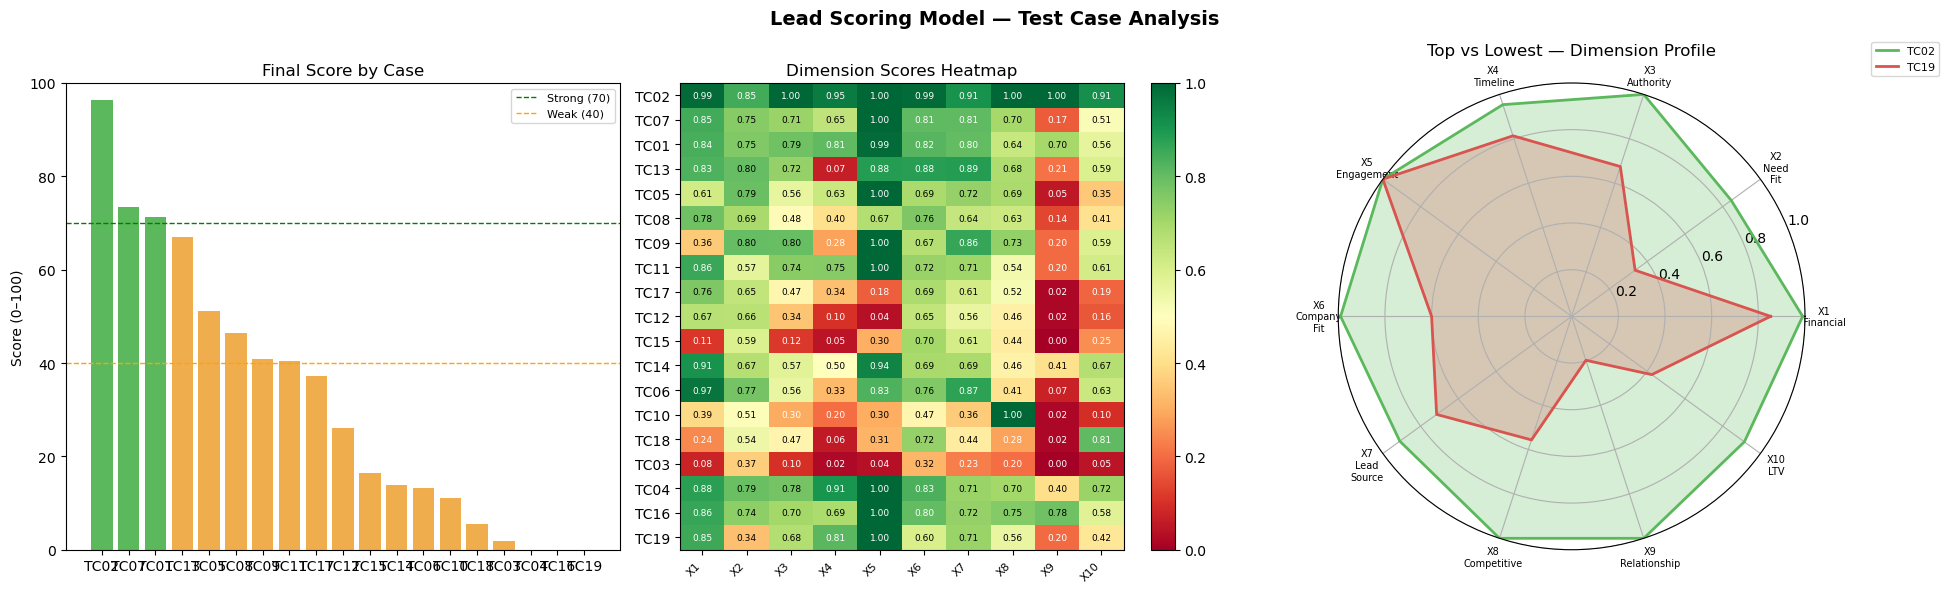

In [72]:
dim_cols = ["X1 Financial","X2 Need Fit","X3 Authority","X4 Timeline",
            "X5 Engagement","X6 Company Fit","X7 Lead Source",
            "X8 Competitive","X9 Relationship","X10 LTV"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Lead Scoring Model — Test Case Analysis", fontsize=14, fontweight="bold")

colors = ["#d9534f" if s == 0 else "#5cb85c" if s >= 70 else "#f0ad4e"
          for s in df_sorted["Score"]]
axes[0].bar(df_sorted["Case ID"], df_sorted["Score"], color=colors)
axes[0].set_title("Final Score by Case")
axes[0].set_ylabel("Score (0–100)")
axes[0].set_ylim(0, 100)
axes[0].axhline(70, color="green",  linestyle="--", linewidth=1, label="Strong (70)")
axes[0].axhline(40, color="orange", linestyle="--", linewidth=1, label="Weak (40)")
axes[0].legend(fontsize=8)

heat_data = df_sorted[dim_cols].values
im = axes[1].imshow(heat_data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
axes[1].set_xticks(range(len(dim_cols)))
axes[1].set_xticklabels([c.split(" ")[0] for c in dim_cols], rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(len(df_sorted)))
axes[1].set_yticklabels(df_sorted["Case ID"])
axes[1].set_title("Dimension Scores Heatmap")
plt.colorbar(im, ax=axes[1])

for i in range(len(df_sorted)):
    for j in range(len(dim_cols)):
        axes[1].text(j, i, f"{heat_data[i, j]:.2f}",
                     ha="center", va="center", fontsize=6.5,
                     color="black" if 0.3 < heat_data[i, j] < 0.8 else "white")

top_vals  = df_sorted.iloc[0][dim_cols].values.astype(float)
bot_vals  = df_sorted.iloc[-1][dim_cols].values.astype(float)
labels    = [c.replace(" ", "\n") for c in dim_cols]
N         = len(dim_cols)
angles    = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

top_vals  = np.append(top_vals, top_vals[0])
bot_vals  = np.append(bot_vals, bot_vals[0])
angles   += angles[:1]

ax3 = axes[2]
ax3.remove()
ax3 = fig.add_subplot(1, 3, 3, polar=True)
ax3.plot(angles, top_vals,  color="#5cb85c", linewidth=2, label=df_sorted.iloc[0]["Case ID"])
ax3.fill(angles, top_vals,  color="#5cb85c", alpha=0.25)
ax3.plot(angles, bot_vals,  color="#d9534f", linewidth=2, label=df_sorted.iloc[-1]["Case ID"])
ax3.fill(angles, bot_vals,  color="#d9534f", alpha=0.25)
ax3.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=7)
ax3.set_ylim(0, 1)
ax3.set_title("Top vs Lowest — Dimension Profile", pad=20)
ax3.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()


In [73]:
df_sorted.to_csv("lead_scores_results.csv", index=False)
print("Exported → lead_scores_results.csv")

Exported → lead_scores_results.csv
